
# 1. Libraries


In [65]:
import pandas as pd
import numpy as np
import glob
import os
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")



# 2. Data Path and Loading


In [66]:
DATA_DIR = Path("../data/eye_tracking")

In [67]:
csv_files = sorted(DATA_DIR.glob("*.csv"))
print(csv_files[:3])

[PosixPath('../data/eye_tracking/01_ET_Data_2026-02-19.csv'), PosixPath('../data/eye_tracking/02_ET_Data_2026-03-10.csv')]


In [68]:
file_path = csv_files[1]  # Christian on-boarding

df = pd.read_csv(file_path, low_memory=False)

# extract participant_id from filename
participant_id = file_path.name[:2]
df["participant_id"] = participant_id

print(df.shape)

(384510, 61)


In [28]:
df

,gaze_capture_time,raw_timestamp,relative_to_unix_epoch_timestamp,focus_distance,frame_number,stability,status,gaze_forward_x,gaze_forward_y,gaze_forward_z,...,trial_number,model_visibility_state,object_position_x,object_position_y,object_position_z,object_rotation_x,object_rotation_y,object_rotation_z,object_rotation_w,participant_id
0,1000325398422099900,1773140944969,41.12195,2.000000,525251,0.293504,Valid,0.012164,-0.266522,0.963752,...,0,0,-1.06,0.00,0.93,0.0,0.000000,0.0,1.000000,02
1,1000325398427100300,1773140944973,41.12195,2.000000,525252,0.315788,Valid,0.013124,-0.265512,0.964018,...,0,0,-1.06,0.00,0.93,0.0,0.000000,0.0,1.000000,02
2,1000325398432112600,1773140944973,41.12195,2.000000,525253,0.354264,Valid,0.014052,-0.264599,0.964256,...,0,0,-1.06,0.00,0.93,0.0,0.000000,0.0,1.000000,02
3,1000325398437113000,1773140944973,41.12195,2.000000,525254,0.441358,Valid,0.014769,-0.263616,0.964515,...,0,0,-1.06,0.00,0.93,0.0,0.000000,0.0,1.000000,02
4,1000325398442101200,1773140944973,41.12195,2.000000,525255,0.473352,Valid,0.015610,-0.262661,0.964762,...,0,0,-1.06,0.00,0.93,0.0,0.000000,0.0,1.000000,02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
384505,1000328184386556900,1773143730444,1607.74300,1.276645,1082229,1.000000,Valid,-0.036495,0.168651,0.985000,...,6,0,3.25,1.52,-0.11,0.0,-0.707107,0.0,0.707107,02
384506,1000328184391558700,1773143730454,1607.75400,1.277654,1082230,0.998679,Valid,-0.036406,0.169091,0.984928,...,6,0,3.25,1.52,-0.11,0.0,-0.707107,0.0,0.707107,02
384507,1000328184396558500,1773143730454,1607.75400,1.278499,1082231,0.993781,Valid,-0.036322,0.169536,0.984854,...,6,0,3.25,1.52,-0.11,0.0,-0.707107,0.0,0.707107,02
384508,1000328184401558700,1773143730465,1607.76500,1.277999,1082232,0.982768,Valid,-0.036273,0.170024,0.984772,...,6,0,3.25,1.52,-0.11,0.0,-0.707107,0.0,0.707107,02


# Estimate Sampling Rate

In [69]:
t = pd.to_numeric(df["gaze_capture_time"], errors="coerce")
dt_ns = t.diff().dropna()

median_dt_ns = dt_ns.median()
sampling_rate_hz = 1e9 / median_dt_ns

print(f"Estimated sampling rate: {sampling_rate_hz:.2f} Hz")
print(f"Median sample interval: {median_dt_ns:.0f} ns")
print(f"Median sample interval: {median_dt_ns / 1e6:.3f} ms")

Estimated sampling rate: 199.98 Hz
Median sample interval: 5000600 ns
Median sample interval: 5.001 ms


# Preprocessing function

In [70]:
def cleaning_function(df: pd.DataFrame) -> pd.DataFrame:
    """
    Preprocess eye-tracking data for analysis.

    Steps:

       - remove training models (TM) and NaN
 ......
    """

    df = df.copy()

    mask = (
        df["model_name"].notna() &
        (~df["model_name"].str.contains("TM", na=False))
    )
    df = df.loc[mask].copy()


    return df

In [71]:
df_clean = cleaning_function(df)

In [58]:
df_clean

,gaze_capture_time,raw_timestamp,relative_to_unix_epoch_timestamp,focus_distance,frame_number,stability,status,gaze_forward_x,gaze_forward_y,gaze_forward_z,...,trial_number,model_visibility_state,object_position_x,object_position_y,object_position_z,object_rotation_x,object_rotation_y,object_rotation_z,object_rotation_w,participant_id
44844,1000325694741666500,1773141240816,336.4777,0.975025,584492,0.821958,Valid,0.013115,0.144055,0.989483,...,1,0,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02
44845,1000325694746666700,1773141240816,336.4777,0.977628,584493,0.817059,Valid,0.013078,0.144172,0.989466,...,1,0,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02
44846,1000325694751663700,1773141240816,336.4777,0.980051,584494,0.827888,Valid,0.013039,0.144279,0.989451,...,1,0,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02
44847,1000325694756664500,1773141240816,336.4777,0.982777,584495,0.820999,Valid,0.013003,0.144336,0.989443,...,1,0,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02
44848,1000325694761666200,1773141240824,336.4866,0.985244,584496,0.822582,Valid,0.012964,0.144379,0.989437,...,1,0,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
381611,1000328169625686100,1773143715702,1593.0000,0.677271,1079278,0.281021,Valid,0.285666,-0.076886,0.955240,...,6,0,0.75,0.975,-0.70,0.0,0.000000,0.0,1.000000,02
381612,1000328169630684400,1773143715702,1593.0000,0.681785,1079279,0.310471,Valid,0.287534,-0.074987,0.954831,...,6,0,0.75,0.975,-0.70,0.0,0.000000,0.0,1.000000,02
381613,1000328169635683800,1773143715702,1593.0000,0.681963,1079280,0.328037,Valid,0.288786,-0.073097,0.954599,...,6,0,0.75,0.975,-0.70,0.0,0.000000,0.0,1.000000,02
381614,1000328169640683200,1773143715702,1593.0000,0.681368,1079281,0.382888,Valid,0.289915,-0.071516,0.954377,...,6,0,0.75,0.975,-0.70,0.0,0.000000,0.0,1.000000,02


# Time Function

In [72]:
def add_time_per_model(df, time_col: str = "gaze_capture_time"):
    """
    Add time_ms per model_name, respecting experiment order.

    Sorting:
    condition_number → trial_number → time

    Assumes:
    - time_col is in nanoseconds
    - df contains: model_name, condition_number, trial_number
    """

    df = df.copy()

    # correct ordering of experiment
    df = df.sort_values(["condition_number", "trial_number", time_col])

    # compute relative time per model
    t0 = df.groupby("model_name")[time_col].transform("first")

    df["time_ms"] = (df[time_col] - t0) / 1_000_000.0

    return df

In [73]:
df_clean = add_time_per_model(df_clean, time_col="gaze_capture_time")

In [35]:
df_clean

,gaze_capture_time,raw_timestamp,relative_to_unix_epoch_timestamp,focus_distance,frame_number,stability,status,gaze_forward_x,gaze_forward_y,gaze_forward_z,...,model_visibility_state,object_position_x,object_position_y,object_position_z,object_rotation_x,object_rotation_y,object_rotation_z,object_rotation_w,participant_id,time_ms
44844,1000325694741666500,1773141240816,336.4777,0.975025,584492,0.821958,Valid,0.013115,0.144055,0.989483,...,0,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02,0.0000
44845,1000325694746666700,1773141240816,336.4777,0.977628,584493,0.817059,Valid,0.013078,0.144172,0.989466,...,0,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02,5.0002
44846,1000325694751663700,1773141240816,336.4777,0.980051,584494,0.827888,Valid,0.013039,0.144279,0.989451,...,0,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02,9.9972
44847,1000325694756664500,1773141240816,336.4777,0.982777,584495,0.820999,Valid,0.013003,0.144336,0.989443,...,0,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02,14.9980
44848,1000325694761666200,1773141240824,336.4866,0.985244,584496,0.822582,Valid,0.012964,0.144379,0.989437,...,0,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02,19.9997
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
381611,1000328169625686100,1773143715702,1593.0000,0.677271,1079278,0.281021,Valid,0.285666,-0.076886,0.955240,...,0,0.75,0.975,-0.70,0.0,0.000000,0.0,1.000000,02,97592.3892
381612,1000328169630684400,1773143715702,1593.0000,0.681785,1079279,0.310471,Valid,0.287534,-0.074987,0.954831,...,0,0.75,0.975,-0.70,0.0,0.000000,0.0,1.000000,02,97597.3875
381613,1000328169635683800,1773143715702,1593.0000,0.681963,1079280,0.328037,Valid,0.288786,-0.073097,0.954599,...,0,0.75,0.975,-0.70,0.0,0.000000,0.0,1.000000,02,97602.3869
381614,1000328169640683200,1773143715702,1593.0000,0.681368,1079281,0.382888,Valid,0.289915,-0.071516,0.954377,...,0,0.75,0.975,-0.70,0.0,0.000000,0.0,1.000000,02,97607.3863


# 8. Define Valid Samples and Interpolation

In [74]:
FORWARD_COLS = ["gaze_forward_x", "gaze_forward_y", "gaze_forward_z"]
CLEAN_FORWARD_COLS = ["clean_gaze_forward_x", "clean_gaze_forward_y", "clean_gaze_forward_z"]


def good_status(left_status: pd.Series, right_status: pd.Series) -> np.ndarray:
    l = left_status.astype(str).str.lower().str.strip()
    r = right_status.astype(str).str.lower().str.strip()

    allowed_pairs = {
        ("tracked", "tracked"),
        ("tracked", "compensated"),
        ("compensated", "tracked"),
        ("compensated", "compensated")
    }

    good = pd.Series(
        [(ls, rs) in allowed_pairs for ls, rs in zip(l, r)],
        index=left_status.index
    )

    return good.to_numpy(dtype=bool)

def find_runs(mask: np.ndarray):
    mask = np.asarray(mask, dtype=bool)
    idx = np.flatnonzero(mask)

    if len(idx) == 0:
        return []

    runs = []
    start = prev = idx[0]

    for k in idx[1:]:
        if k == prev + 1:
            prev = k
        else:
            runs.append((start, prev))
            start = prev = k

    runs.append((start, prev))
    return runs

def expand_runs(runs, n, pad=2):
    """
    Expand each run by `pad` samples on both sides,
    then merge overlaps.
    """
    if len(runs) == 0:
        return []

    expanded = []
    for a, b in runs:
        aa = max(0, a - pad)
        bb = min(n - 1, b + pad)
        expanded.append((aa, bb))

    expanded.sort()
    merged = [expanded[0]]

    for a, b in expanded[1:]:
        prev_a, prev_b = merged[-1]
        if a <= prev_b + 1:
            merged[-1] = (prev_a, max(prev_b, b))
        else:
            merged.append((a, b))

    return merged


def normalize_xyz(xyz: np.ndarray) -> np.ndarray:
    xyz = np.asarray(xyz, dtype=float)
    nrm = np.linalg.norm(xyz, axis=1)
    out = np.full_like(xyz, np.nan, dtype=float)
    good = np.isfinite(nrm) & (nrm > 1e-8) & np.all(np.isfinite(xyz), axis=1)
    out[good] = xyz[good] / nrm[good, None]
    return out


def interpolate_segment(sub: pd.DataFrame, forward_cols=FORWARD_COLS, pad: int = 2) -> pd.DataFrame:
    sub = sub.sort_values("time_ms").copy()
    t = sub["time_ms"].to_numpy(dtype=float)

    xyz = np.column_stack([
        pd.to_numeric(sub[c], errors="coerce").to_numpy(dtype=float)
        for c in forward_cols
    ])

    good = good_status(sub["left_status"], sub["right_status"])
    bad = ~good
    bad_runs = find_runs(bad)

    n = len(sub)
    is_interpolated = np.zeros(n, dtype=bool)

    clean = xyz.copy()

    # expand bad runs by buffer
    buffered_runs = expand_runs(bad_runs, n=n, pad=pad)

    # set buffered regions to NaN before interpolation
    for a, b in buffered_runs:
        clean[a:b+1, :] = np.nan

    for a, b in buffered_runs:
        left = a - 1
        right = b + 1

        bracketed = (
            left >= 0 and
            right < n and
            np.all(np.isfinite(xyz[left])) and
            np.all(np.isfinite(xyz[right]))
        )

        if bracketed:
            for dim in range(3):
                clean[a:b+1, dim] = np.interp(
                    t[a:b+1],
                    [t[left], t[right]],
                    [xyz[left, dim], xyz[right, dim]]
                )

            clean[a:b+1, :] = normalize_xyz(clean[a:b+1, :])
            is_interpolated[a:b+1] = True

    sub["good_sample"] = good
    sub["bad_sample"] = bad
    sub["is_interpolated"] = is_interpolated

    for j, c in enumerate(forward_cols):
        sub[f"clean_{c}"] = clean[:, j]

    return sub


def interpolate_all_segments(df: pd.DataFrame, pad: int = 2) -> pd.DataFrame:
    out = []

    for (cond, trial), sub in df.groupby(["condition_number", "trial_number"], sort=True):
        cleaned = interpolate_segment(sub, forward_cols=FORWARD_COLS, pad=pad)
        cleaned["segment_label"] = f"C{int(cond)}_T{int(trial)}"
        out.append(cleaned)

    return (
        pd.concat(out, axis=0)
        .sort_values(["condition_number", "trial_number", "time_ms"])
        .reset_index(drop=True)
    )

In [75]:
df_clean = interpolate_all_segments(df_clean)

## Smoothing the data: 5-median filter

In [76]:
def median_filter_valid_runs(x: pd.Series, window: int = 5) -> pd.Series:
    y = x.to_numpy(dtype=float).copy()
    out = y.copy()

    valid = np.isfinite(y)
    idx = np.flatnonzero(valid)

    if len(idx) == 0:
        return pd.Series(out, index=x.index)

    runs = []
    start = prev = idx[0]

    for k in idx[1:]:
        if k == prev + 1:
            prev = k
        else:
            runs.append((start, prev))
            start = prev = k
    runs.append((start, prev))

    for a, b in runs:
        seg = pd.Series(y[a:b+1])

        # centered 5-point median, allowing shorter windows at edges
        filt = seg.rolling(window=window, center=True, min_periods=1).median()

        out[a:b+1] = filt.to_numpy()

    return pd.Series(out, index=x.index)

WINDOW = 5

for col in CLEAN_FORWARD_COLS:
    df_clean[col] = (
        df_clean.groupby(["condition_number", "trial_number"])[col]
        .transform(lambda x: median_filter_valid_runs(x, window=WINDOW))
    )

# renormalize after median filtering
xyz = df_clean[CLEAN_FORWARD_COLS].to_numpy(dtype=float)
df_clean[CLEAN_FORWARD_COLS] = normalize_xyz(xyz)

In [77]:
# 7) QUALITY-CONTROL SUMMARY
qc = (
    df_clean.groupby(["condition_number", "trial_number"])
    .agg(
        n_samples=("time_ms", "size"),
        n_bad=("bad_sample", "sum"),
        n_interpolated=("is_interpolated", "sum"),
    )
    .reset_index()
)

# percentages
qc["pct_bad"] = 100 * qc["n_bad"] / qc["n_samples"]
qc["pct_interpolated"] = 100 * qc["n_interpolated"] / qc["n_samples"]

print(qc.to_string(index=False))

 condition_number  trial_number  n_samples  n_bad  n_interpolated  pct_bad  pct_interpolated
                1             1       4001    215             270 5.373657          6.748313
                1             2      21653    408             540 1.884265          2.493881
                1             3      10276    221             303 2.150642          2.948618
                1             4      12824    337             449 2.627885          3.501248
                1             5       4651    153             201 3.289615          4.321651
                1             6      15074    447             549 2.965371          3.642033
                2             1      10647    263             315 2.470179          2.958580
                2             2       3546     83             117 2.340666          3.299492
                2             3      18793   1402            1530 7.460225          8.141329
                2             4       3706    125             155 3.37

In [ ]:
df_clean

In [78]:
def add_angular_velocity(df, time_col="gaze_capture_time"):
    """
    Compute gaze angular velocity (deg/s) from Varjo gaze_forward vectors.

    Method
    ------
    1. Take consecutive 3D gaze direction vectors.
    2. Compute the angle between them with:
           angle = atan2(||g_prev x g_curr||, g_prev · g_curr)
       This is numerically stable.
    3. Divide by the time difference in seconds.
    4. Convert from rad/s to deg/s.

    Assumptions
    -----------
    - gaze_forward_x/y/z describe gaze direction.
    - time_col is in nanoseconds.
    - Velocity should be computed within each participant/model block.

    Returns
    -------
    df : copy of input dataframe with a new column:
         - angular_velocity
    """
    df = df.copy()

    # Sort so consecutive rows are truly consecutive in time
    df = df.sort_values(
        ["condition_number", "trial_number", time_col]
    )

    # Initialize output column
    df["angular_velocity"] = np.nan

    # Compute separately within each continuous block
    for (_, _), sub in df.groupby(["condition_number", "trial_number"], sort=False):
        idx = sub.index

        # Extract gaze direction vectors
        g = sub[[
            "clean_gaze_forward_x",
            "clean_gaze_forward_y",
            "clean_gaze_forward_z"
        ]].to_numpy(dtype=float)

        # Normalize vectors just in case they are not perfectly unit length
        norms = np.linalg.norm(g, axis=1, keepdims=True)
        g = g / np.clip(norms, 1e-12, None)

        # Previous and current vectors
        g_prev = g[:-1]
        g_curr = g[1:]

        # Angle between consecutive vectors:
        # angle = atan2(||cross||, dot)
        cross_norm = np.linalg.norm(np.cross(g_prev, g_curr), axis=1)
        dot_prod = np.sum(g_prev * g_curr, axis=1)
        angles_rad = np.arctan2(cross_norm, dot_prod)

        # Time difference in seconds (timestamps are in nanoseconds)
        t = sub[time_col].to_numpy(dtype=np.int64)
        dt = np.diff(t) * 1e-9

        # Prepare output for this block
        vel = np.full(len(sub), np.nan)

        # Only compute where dt is valid
        valid = dt > 0
        vel[1:][valid] = np.degrees(angles_rad[valid] / dt[valid])

        # Write back into dataframe
        df.loc[idx, "angular_velocity"] = vel

    return df

In [79]:
df_clean = add_angular_velocity(df_clean, time_col="gaze_capture_time")

In [80]:
def at_mad_threshold(angular_vel, th_0=200.0, min_samples=10, tol=1.0, max_iter=50):
    """
    Compute an adaptive saccade threshold from angular velocity using MAD.

    Based on the iterative MAD idea from Voloh et al. (2020), adjusted in the
    style used by Keshava et al. (2023).

    Parameters
    ----------
    angular_vel : array-like
        Angular velocity values in deg/s.
    th_0 : float, default=200.0
        Initial threshold in deg/s.
    min_samples : int, default=10
        Minimum number of valid samples required to estimate a threshold.
    tol : float, default=1.0
        Convergence tolerance in deg/s.
    max_iter : int, default=50
        Maximum number of iterations.

    Returns
    -------
    saccade_thresh : float
        Final threshold in deg/s. Returns NaN if threshold cannot be estimated.
    threshs : list[float]
        Threshold values across iterations.
    """
    v = pd.to_numeric(pd.Series(angular_vel), errors="coerce").to_numpy(dtype=float)
    v = v[np.isfinite(v)]

    if len(v) < min_samples:
        return np.nan, []

    threshs = []
    current_th = float(th_0)

    for _ in range(max_iter):
        threshs.append(current_th)

        subset = v[v < current_th]
        subset = subset[np.isfinite(subset)]

        if len(subset) < min_samples:
            return np.nan, threshs

        median = np.median(subset)
        mad = np.median(np.abs(subset - median))

        next_th = median + 3.0 * 1.486 * mad

        if not np.isfinite(next_th):
            return np.nan, threshs

        if abs(current_th - next_th) <= tol:
            threshs.append(float(next_th))
            return float(next_th), threshs

        current_th = float(next_th)

    return float(current_th), threshs


def compute_mad_thresholds_per_trial(
    df,
    vel_col="angular_velocity",
    group_cols=("condition_number", "trial_number"),
    th_0=200.0,
    min_samples=10,
    tol=1.0,
    max_iter=50,
):
    """
    Compute one MAD-based angular velocity threshold per trial.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe containing angular velocity and grouping columns.
    vel_col : str, default="angular_velocity"
        Column with angular velocity in deg/s.
    group_cols : tuple[str, str], default=("condition_number", "trial_number")
        Columns defining one trial/segment.
    th_0 : float, default=200.0
        Initial threshold in deg/s.
    min_samples : int, default=10
        Minimum valid samples required for threshold estimation.
    tol : float, default=1.0
        Convergence tolerance in deg/s.
    max_iter : int, default=50
        Maximum number of MAD iterations.

    Returns
    -------
    thresholds_df : pd.DataFrame
        One row per trial with:
        - condition_number
        - trial_number
        - mad_threshold
        - n_valid_velocity_samples
        - threshold_trace
    """
    rows = []

    for keys, sub in df.groupby(list(group_cols), sort=True):
        vel = pd.to_numeric(sub[vel_col], errors="coerce")
        valid_vel = vel[np.isfinite(vel)]

        threshold, trace = at_mad_threshold(
            valid_vel,
            th_0=th_0,
            min_samples=min_samples,
            tol=tol,
            max_iter=max_iter,
        )

        if not isinstance(keys, tuple):
            keys = (keys,)

        row = dict(zip(group_cols, keys))
        row["mad_threshold"] = threshold
        row["n_valid_velocity_samples"] = int(valid_vel.shape[0])
        row["threshold_trace"] = trace
        rows.append(row)

    return pd.DataFrame(rows)


def add_mad_threshold_per_trial(
    df,
    thresholds_df,
    group_cols=("condition_number", "trial_number"),
    threshold_col="mad_threshold",
):
    """
    Merge the per-trial MAD threshold back into the sample-level dataframe.
    """
    return df.merge(
        thresholds_df[list(group_cols) + [threshold_col]],
        on=list(group_cols),
        how="left",
    )

In [81]:
thresholds_df = compute_mad_thresholds_per_trial(df_clean)

In [82]:
df_clean = add_mad_threshold_per_trial(df_clean, thresholds_df)

In [83]:
thresholds_df

,condition_number,trial_number,mad_threshold,n_valid_velocity_samples,threshold_trace
0,1,1,47.545356,4000,"[200.0, 67.12252098048681, 56.73807653430477, ..."
1,1,2,30.513328,21652,"[200.0, 47.546587696019955, 35.66597461796522,..."
2,1,3,39.929693,10275,"[200.0, 61.44415402006579, 47.319312465055994,..."
3,1,4,38.122529,12823,"[200.0, 60.85333688610654, 45.242153186966384,..."
4,1,5,46.450668,4650,"[200.0, 63.049954925827514, 50.54976182789622,..."
5,1,6,30.741801,15073,"[200.0, 45.722265484097775, 35.12651702032802,..."
6,2,1,42.348515,10646,"[200.0, 64.76391384959867, 50.10219028061774, ..."
7,2,2,42.990368,3545,"[200.0, 61.47558527203046, 47.98479963808909, ..."
8,2,3,34.941136,18792,"[200.0, 51.882216183104255, 40.598495947675616..."
9,2,4,49.484594,3705,"[200.0, 66.7542871314604, 55.494457376753374, ..."


In [84]:
df_clean.head()

,gaze_capture_time,raw_timestamp,relative_to_unix_epoch_timestamp,focus_distance,frame_number,stability,status,gaze_forward_x,gaze_forward_y,gaze_forward_z,...,time_ms,good_sample,bad_sample,is_interpolated,clean_gaze_forward_x,clean_gaze_forward_y,clean_gaze_forward_z,segment_label,angular_velocity,mad_threshold
0,1000325694741666500,1773141240816,336.4777,0.975025,584492,0.821958,Valid,0.013115,0.144055,0.989483,...,0.0000,True,False,False,0.013078,0.144172,0.989466,C1_T1,NaN,47.545356
1,1000325694746666700,1773141240816,336.4777,0.977628,584493,0.817059,Valid,0.013078,0.144172,0.989466,...,5.0002,True,False,False,0.013059,0.144225,0.989459,C1_T1,0.653459,47.545356
2,1000325694751663700,1773141240816,336.4777,0.980051,584494,0.827888,Valid,0.013039,0.144279,0.989451,...,9.9972,True,False,False,0.013039,0.144279,0.989451,C1_T1,0.653878,47.545356
3,1000325694756664500,1773141240816,336.4777,0.982777,584495,0.820999,Valid,0.013003,0.144336,0.989443,...,14.9980,True,False,False,0.013003,0.144336,0.989443,C1_T1,0.791661,47.545356
4,1000325694761666200,1773141240824,336.4866,0.985244,584496,0.822582,Valid,0.012964,0.144379,0.989437,...,19.9997,True,False,False,0.012964,0.144336,0.989444,C1_T1,0.443740,47.545356


In [85]:
df_clean

,gaze_capture_time,raw_timestamp,relative_to_unix_epoch_timestamp,focus_distance,frame_number,stability,status,gaze_forward_x,gaze_forward_y,gaze_forward_z,...,time_ms,good_sample,bad_sample,is_interpolated,clean_gaze_forward_x,clean_gaze_forward_y,clean_gaze_forward_z,segment_label,angular_velocity,mad_threshold
0,1000325694741666500,1773141240816,336.4777,0.975025,584492,0.821958,Valid,0.013115,0.144055,0.989483,...,0.0000,True,False,False,0.013078,0.144172,0.989466,C1_T1,NaN,47.545356
1,1000325694746666700,1773141240816,336.4777,0.977628,584493,0.817059,Valid,0.013078,0.144172,0.989466,...,5.0002,True,False,False,0.013059,0.144225,0.989459,C1_T1,0.653459,47.545356
2,1000325694751663700,1773141240816,336.4777,0.980051,584494,0.827888,Valid,0.013039,0.144279,0.989451,...,9.9972,True,False,False,0.013039,0.144279,0.989451,C1_T1,0.653878,47.545356
3,1000325694756664500,1773141240816,336.4777,0.982777,584495,0.820999,Valid,0.013003,0.144336,0.989443,...,14.9980,True,False,False,0.013003,0.144336,0.989443,C1_T1,0.791661,47.545356
4,1000325694761666200,1773141240824,336.4866,0.985244,584496,0.822582,Valid,0.012964,0.144379,0.989437,...,19.9997,True,False,False,0.012964,0.144336,0.989444,C1_T1,0.443740,47.545356
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
202964,1000328169625686100,1773143715702,1593.0000,0.677271,1079278,0.281021,Valid,0.285666,-0.076886,0.955240,...,97592.3892,True,False,False,0.285666,-0.076886,0.955240,C3_T6,37.569699,26.768627
202965,1000328169630684400,1773143715702,1593.0000,0.681785,1079279,0.310471,Valid,0.287534,-0.074987,0.954831,...,97597.3875,True,False,False,0.287534,-0.074987,0.954830,C3_T6,30.886675,26.768627
202966,1000328169635683800,1773143715702,1593.0000,0.681963,1079280,0.328037,Valid,0.288786,-0.073097,0.954599,...,97602.3869,True,False,False,0.288786,-0.073097,0.954599,C3_T6,26.124483,26.768627
202967,1000328169640683200,1773143715702,1593.0000,0.681368,1079281,0.382888,Valid,0.289915,-0.071516,0.954377,...,97607.3863,True,False,False,0.289351,-0.072306,0.954488,C3_T6,11.203345,26.768627


In [51]:
def add_velocity_category(df,
                          vel_col="angular_velocity",
                          threshold_col="mad_threshold",
                          out_col="velocity_category"):
    """
    Add a new column labeling each row as:
    - 'saccade'  if angular_velocity > mad_threshold
    - 'fixation' otherwise

    If either value is missing, the output stays NaN.
    """
    out = df.copy()

    vel = pd.to_numeric(out[vel_col], errors="coerce")
    thr = pd.to_numeric(out[threshold_col], errors="coerce")

    out[out_col] = pd.Series(index=out.index, dtype="object")

    valid = np.isfinite(vel) & np.isfinite(thr)
    out.loc[valid & (vel > thr), out_col] = "saccade"
    out.loc[valid & (vel <= thr), out_col] = "fixation"

    return out


In [52]:
df_clean = add_velocity_category(df_clean)

In [53]:
df_clean

,gaze_capture_time,raw_timestamp,relative_to_unix_epoch_timestamp,focus_distance,frame_number,stability,status,gaze_forward_x,gaze_forward_y,gaze_forward_z,...,good_sample,bad_sample,is_interpolated,clean_gaze_forward_x,clean_gaze_forward_y,clean_gaze_forward_z,segment_label,angular_velocity,mad_threshold,velocity_category
0,1000325694741666500,1773141240816,336.4777,0.975025,584492,0.821958,Valid,0.013115,0.144055,0.989483,...,True,False,False,0.013078,0.144172,0.989466,C1_T1,NaN,47.545356,NaN
1,1000325694746666700,1773141240816,336.4777,0.977628,584493,0.817059,Valid,0.013078,0.144172,0.989466,...,True,False,False,0.013059,0.144225,0.989459,C1_T1,0.653459,47.545356,fixation
2,1000325694751663700,1773141240816,336.4777,0.980051,584494,0.827888,Valid,0.013039,0.144279,0.989451,...,True,False,False,0.013039,0.144279,0.989451,C1_T1,0.653878,47.545356,fixation
3,1000325694756664500,1773141240816,336.4777,0.982777,584495,0.820999,Valid,0.013003,0.144336,0.989443,...,True,False,False,0.013003,0.144336,0.989443,C1_T1,0.791661,47.545356,fixation
4,1000325694761666200,1773141240824,336.4866,0.985244,584496,0.822582,Valid,0.012964,0.144379,0.989437,...,True,False,False,0.012964,0.144336,0.989444,C1_T1,0.443740,47.545356,fixation
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
202964,1000328169625686100,1773143715702,1593.0000,0.677271,1079278,0.281021,Valid,0.285666,-0.076886,0.955240,...,True,False,False,0.285666,-0.076886,0.955240,C3_T6,37.569699,26.768627,saccade
202965,1000328169630684400,1773143715702,1593.0000,0.681785,1079279,0.310471,Valid,0.287534,-0.074987,0.954831,...,True,False,False,0.287534,-0.074987,0.954830,C3_T6,30.886675,26.768627,saccade
202966,1000328169635683800,1773143715702,1593.0000,0.681963,1079280,0.328037,Valid,0.288786,-0.073097,0.954599,...,True,False,False,0.288786,-0.073097,0.954599,C3_T6,26.124483,26.768627,fixation
202967,1000328169640683200,1773143715702,1593.0000,0.681368,1079281,0.382888,Valid,0.289915,-0.071516,0.954377,...,True,False,False,0.289351,-0.072306,0.954488,C3_T6,11.203345,26.768627,fixation


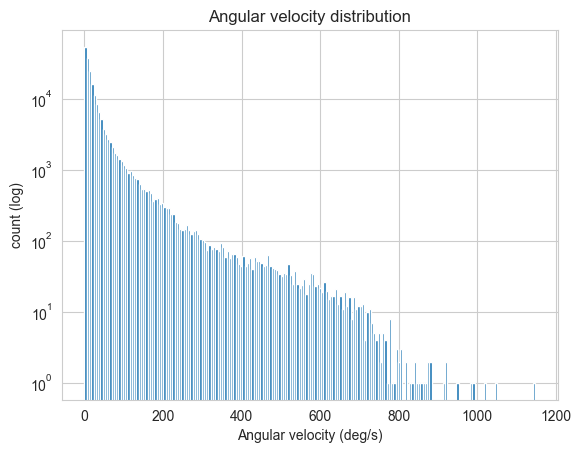

In [20]:
plt.hist(df_clean["angular_velocity"], bins=200)
plt.yscale("log")
plt.xlabel("Angular velocity (deg/s)")
plt.ylabel("count (log)")
plt.title("Angular velocity distribution")
plt.show()

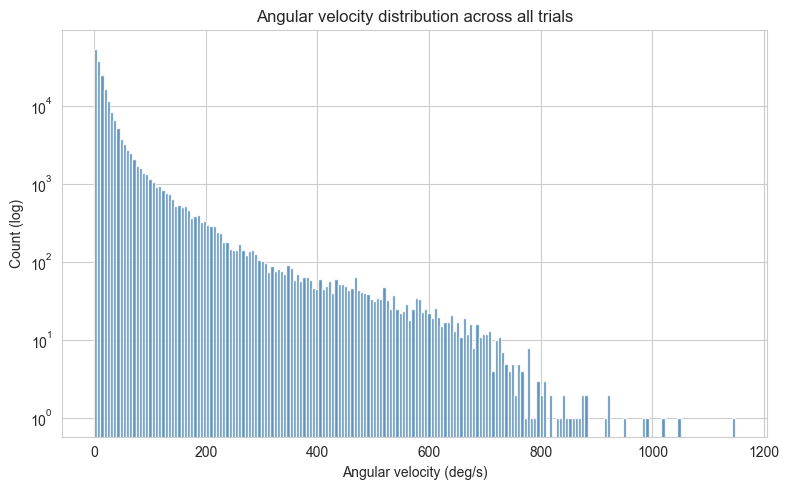

In [80]:
vel = pd.to_numeric(df_clean["angular_velocity"], errors="coerce")
vel = vel[np.isfinite(vel)]

plt.figure(figsize=(8, 5))
plt.hist(vel, bins=200, color="steelblue", alpha=0.85)
plt.yscale("log")
plt.xlabel("Angular velocity (deg/s)")
plt.ylabel("Count (log)")
plt.title("Angular velocity distribution across all trials")
plt.tight_layout()
plt.show()

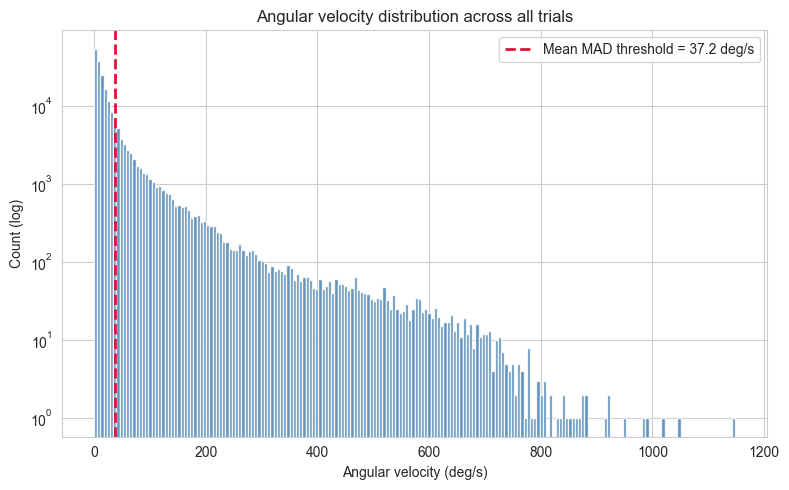

In [81]:
vel = pd.to_numeric(df_clean["angular_velocity"], errors="coerce")
vel = vel[np.isfinite(vel)]

mean_mad_threshold = thresholds_df["mad_threshold"].mean()

plt.figure(figsize=(8, 5))
plt.hist(vel, bins=200, color="steelblue", alpha=0.85)
plt.yscale("log")

plt.axvline(
    mean_mad_threshold,
    color="crimson",
    linestyle="--",
    linewidth=2,
    label=f"Mean MAD threshold = {mean_mad_threshold:.1f} deg/s"
)

plt.xlabel("Angular velocity (deg/s)")
plt.ylabel("Count (log)")
plt.title("Angular velocity distribution across all trials")
plt.legend()
plt.tight_layout()
plt.show()


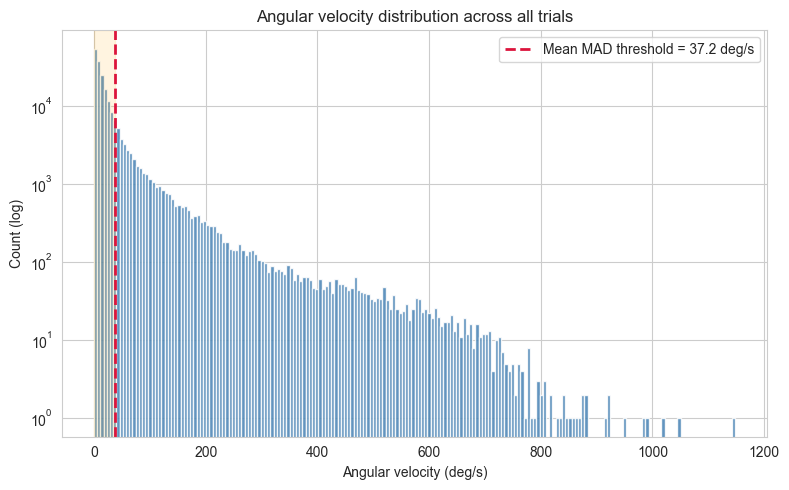

In [83]:
plt.figure(figsize=(8, 5))
plt.hist(vel, bins=200, color="steelblue", alpha=0.85)
plt.yscale("log")

plt.axvspan(0, mean_mad_threshold, color="orange", alpha=0.12)
plt.axvline(
    mean_mad_threshold,
    color="crimson",
    linestyle="--",
    linewidth=2,
    label=f"Mean MAD threshold = {mean_mad_threshold:.1f} deg/s"
)

plt.xlabel("Angular velocity (deg/s)")
plt.ylabel("Count (log)")
plt.title("Angular velocity distribution across all trials")
plt.legend()
plt.tight_layout()
plt.show()

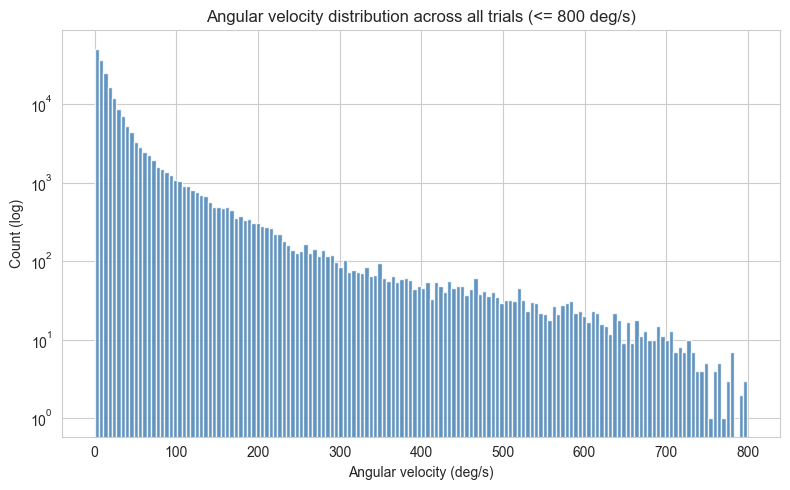

In [82]:
vel_plot = vel[vel <= 800]

plt.figure(figsize=(8, 5))
plt.hist(vel_plot, bins=150, color="steelblue", alpha=0.85)
plt.yscale("log")
plt.xlabel("Angular velocity (deg/s)")
plt.ylabel("Count (log)")
plt.title("Angular velocity distribution across all trials (<= 800 deg/s)")
plt.tight_layout()
plt.show()

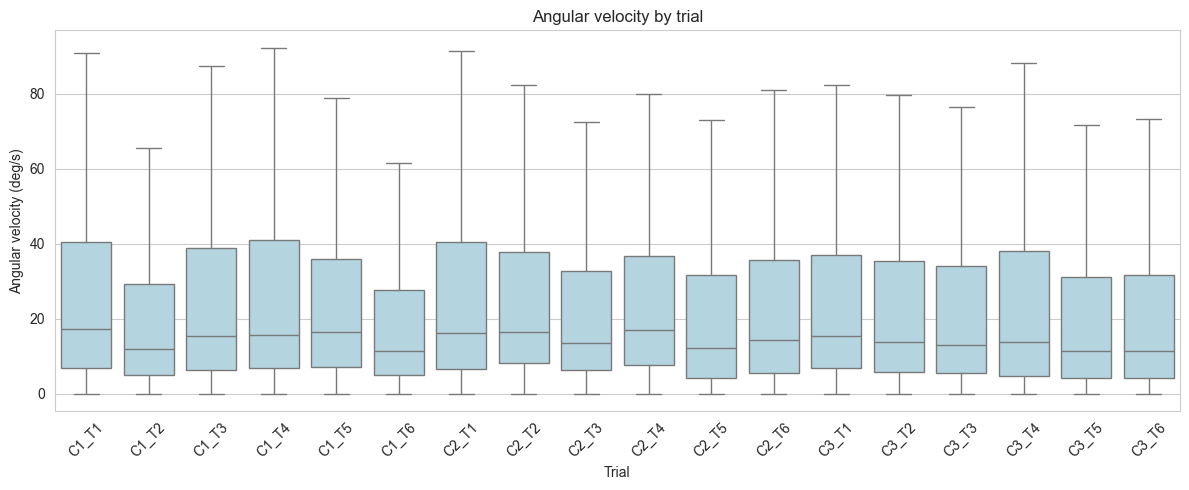

In [70]:
plot_df = df_clean.copy()
plot_df["angular_velocity"] = pd.to_numeric(plot_df["angular_velocity"], errors="coerce")
plot_df = plot_df[np.isfinite(plot_df["angular_velocity"])].copy()

plot_df["trial_label"] = (
    "C" + plot_df["condition_number"].astype(str) +
    "_T" + plot_df["trial_number"].astype(str)
)

plt.figure(figsize=(12, 5))
sns.boxplot(
    data=plot_df,
    x="trial_label",
    y="angular_velocity",
    color="lightblue",
    showfliers=False
)
plt.xticks(rotation=45)
plt.xlabel("Trial")
plt.ylabel("Angular velocity (deg/s)")
plt.title("Angular velocity by trial")
plt.tight_layout()
plt.show()

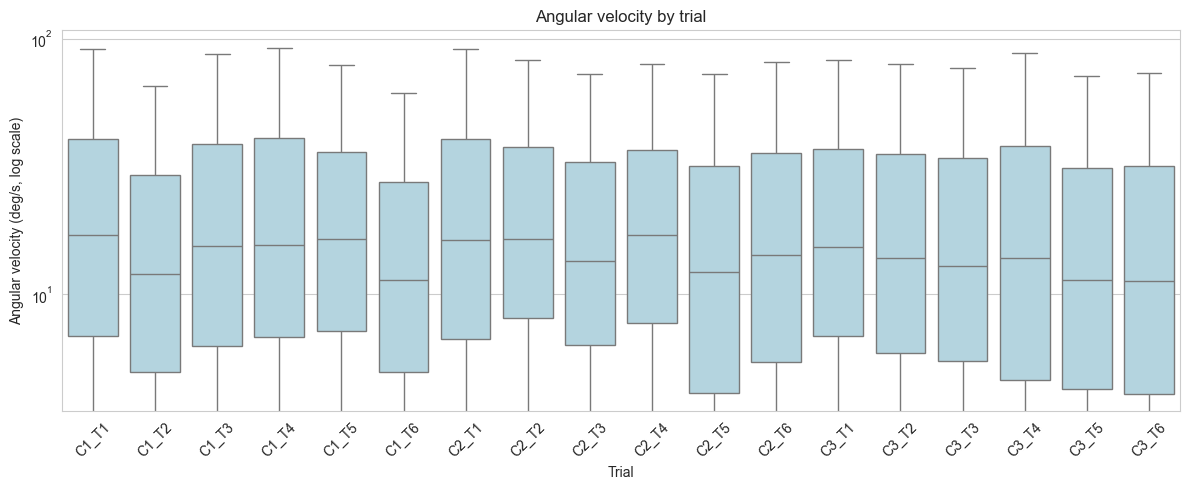

In [71]:
plt.figure(figsize=(12, 5))
sns.boxplot(
    data=plot_df,
    x="trial_label",
    y="angular_velocity",
    color="lightblue",
    showfliers=False
)
plt.yscale("log")
plt.xticks(rotation=45)
plt.xlabel("Trial")
plt.ylabel("Angular velocity (deg/s, log scale)")
plt.title("Angular velocity by trial")
plt.tight_layout()
plt.show()

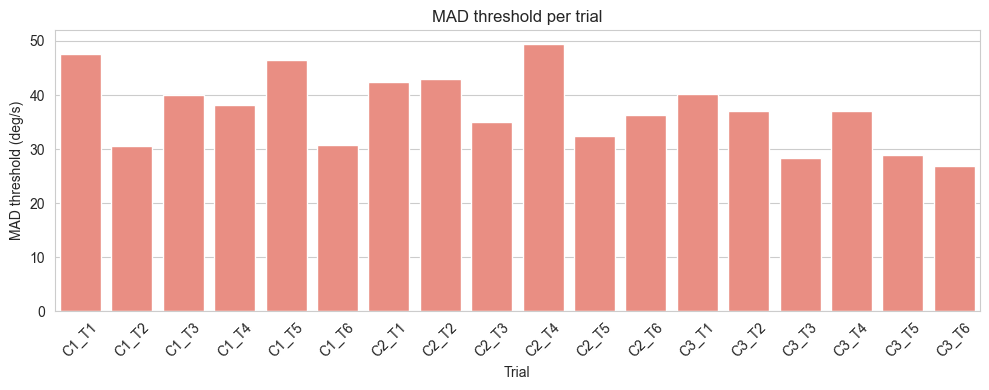

In [72]:
thr_df = thresholds_df.copy()
thr_df["trial_label"] = (
    "C" + thr_df["condition_number"].astype(str) +
    "_T" + thr_df["trial_number"].astype(str)
)

plt.figure(figsize=(10, 4))
sns.barplot(
    data=thr_df,
    x="trial_label",
    y="mad_threshold",
    color="salmon"
)
plt.xticks(rotation=45)
plt.xlabel("Trial")
plt.ylabel("MAD threshold (deg/s)")
plt.title("MAD threshold per trial")
plt.tight_layout()
plt.show()

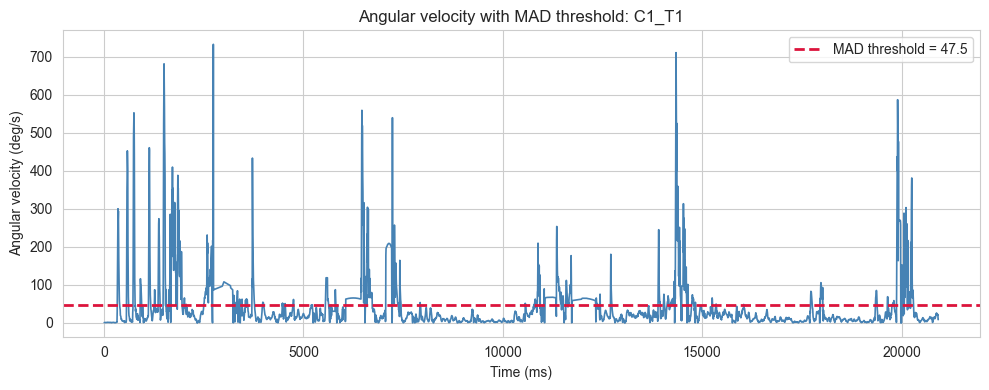

In [73]:
cond = 1
trial = 1

sub = df_clean[
    (df_clean["condition_number"] == cond) &
    (df_clean["trial_number"] == trial)
].copy()

thr = thresholds_df.loc[
    (thresholds_df["condition_number"] == cond) &
    (thresholds_df["trial_number"] == trial),
    "mad_threshold"
].iloc[0]

plt.figure(figsize=(10, 4))
plt.plot(sub["time_ms"], sub["angular_velocity"], lw=1.2, color="steelblue")
plt.axhline(thr, color="crimson", ls="--", lw=2, label=f"MAD threshold = {thr:.1f}")
plt.xlabel("Time (ms)")
plt.ylabel("Angular velocity (deg/s)")
plt.title(f"Angular velocity with MAD threshold: C{cond}_T{trial}")
plt.legend()
plt.tight_layout()
plt.show()

In [86]:


# Keep a clean trial order
trial_info = (
    df_clean[["condition_number", "trial_number"]]
    .drop_duplicates()
    .sort_values(["condition_number", "trial_number"])
    .reset_index(drop=True)
)

n_trials = len(trial_info)
ncols = 3
nrows = math.ceil(n_trials / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4 * nrows), sharey=True)
axes = np.array(axes).reshape(-1)

for ax, row in zip(axes, trial_info.itertuples(index=False)):
    cond = row.condition_number
    trial = row.trial_number

    sub = df_clean[
        (df_clean["condition_number"] == cond) &
        (df_clean["trial_number"] == trial)
    ].copy()

    sub["angular_velocity"] = pd.to_numeric(sub["angular_velocity"], errors="coerce")
    sub["time_ms"] = pd.to_numeric(sub["time_ms"], errors="coerce")
    sub = sub[np.isfinite(sub["time_ms"])].sort_values("time_ms")

    thr_match = thresholds_df.loc[
        (thresholds_df["condition_number"] == cond) &
        (thresholds_df["trial_number"] == trial),
        "mad_threshold"
    ]

    thr = thr_match.iloc[0] if len(thr_match) > 0 else np.nan

    ax.plot(
        sub["time_ms"],
        sub["angular_velocity"],
        lw=1.0,
        color="steelblue"
    )

    if np.isfinite(thr):
        ax.axhline(
            thr,
            color="crimson",
            ls="--",
            lw=1.8,
            label=f"MAD threshold = {thr:.1f}"
        )

    ax.set_title(f"Condition {int(cond)}, Trial {int(trial)}", fontsize=11)
    ax.set_xlabel("Time (ms)")
    ax.set_ylabel("Angular velocity (deg/s)")
    ax.legend(fontsize=9, loc="upper right")

# Hide any unused subplot axes
for j in range(len(trial_info), len(axes)):
    axes[j].axis("off")

fig.suptitle("Angular velocity with MAD threshold across all trials", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


NameError: name 'math' is not defined

In [89]:
df_clean

,gaze_capture_time,raw_timestamp,relative_to_unix_epoch_timestamp,focus_distance,frame_number,stability,status,gaze_forward_x,gaze_forward_y,gaze_forward_z,...,time_ms,good_sample,bad_sample,is_interpolated,clean_gaze_forward_x,clean_gaze_forward_y,clean_gaze_forward_z,segment_label,angular_velocity,mad_threshold
0,1000325694741666500,1773141240816,336.4777,0.975025,584492,0.821958,Valid,0.013115,0.144055,0.989483,...,0.0000,True,False,False,0.013078,0.144172,0.989466,C1_T1,NaN,47.545356
1,1000325694746666700,1773141240816,336.4777,0.977628,584493,0.817059,Valid,0.013078,0.144172,0.989466,...,5.0002,True,False,False,0.013059,0.144225,0.989459,C1_T1,0.653459,47.545356
2,1000325694751663700,1773141240816,336.4777,0.980051,584494,0.827888,Valid,0.013039,0.144279,0.989451,...,9.9972,True,False,False,0.013039,0.144279,0.989451,C1_T1,0.653878,47.545356
3,1000325694756664500,1773141240816,336.4777,0.982777,584495,0.820999,Valid,0.013003,0.144336,0.989443,...,14.9980,True,False,False,0.013003,0.144336,0.989443,C1_T1,0.791661,47.545356
4,1000325694761666200,1773141240824,336.4866,0.985244,584496,0.822582,Valid,0.012964,0.144379,0.989437,...,19.9997,True,False,False,0.012964,0.144336,0.989444,C1_T1,0.443740,47.545356
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
202964,1000328169625686100,1773143715702,1593.0000,0.677271,1079278,0.281021,Valid,0.285666,-0.076886,0.955240,...,97592.3892,True,False,False,0.285666,-0.076886,0.955240,C3_T6,37.569699,26.768627
202965,1000328169630684400,1773143715702,1593.0000,0.681785,1079279,0.310471,Valid,0.287534,-0.074987,0.954831,...,97597.3875,True,False,False,0.287534,-0.074987,0.954830,C3_T6,30.886675,26.768627
202966,1000328169635683800,1773143715702,1593.0000,0.681963,1079280,0.328037,Valid,0.288786,-0.073097,0.954599,...,97602.3869,True,False,False,0.288786,-0.073097,0.954599,C3_T6,26.124483,26.768627
202967,1000328169640683200,1773143715702,1593.0000,0.681368,1079281,0.382888,Valid,0.289915,-0.071516,0.954377,...,97607.3863,True,False,False,0.289351,-0.072306,0.954488,C3_T6,11.203345,26.768627


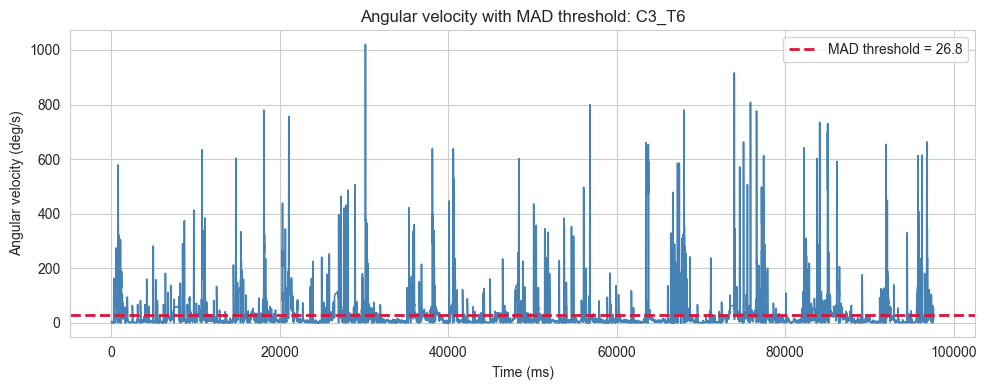

In [87]:
cond = 3
trial = 6

sub = df_clean[
    (df_clean["condition_number"] == cond) &
    (df_clean["trial_number"] == trial)
].copy()

thr = thresholds_df.loc[
    (thresholds_df["condition_number"] == cond) &
    (thresholds_df["trial_number"] == trial),
    "mad_threshold"
].iloc[0]

plt.figure(figsize=(10, 4))
plt.plot(sub["time_ms"], sub["angular_velocity"], lw=1.2, color="steelblue")
plt.axhline(thr, color="crimson", ls="--", lw=2, label=f"MAD threshold = {thr:.1f}")
plt.xlabel("Time (ms)")
plt.ylabel("Angular velocity (deg/s)")
plt.title(f"Angular velocity with MAD threshold: C{cond}_T{trial}")
plt.legend()
plt.tight_layout()
plt.show()


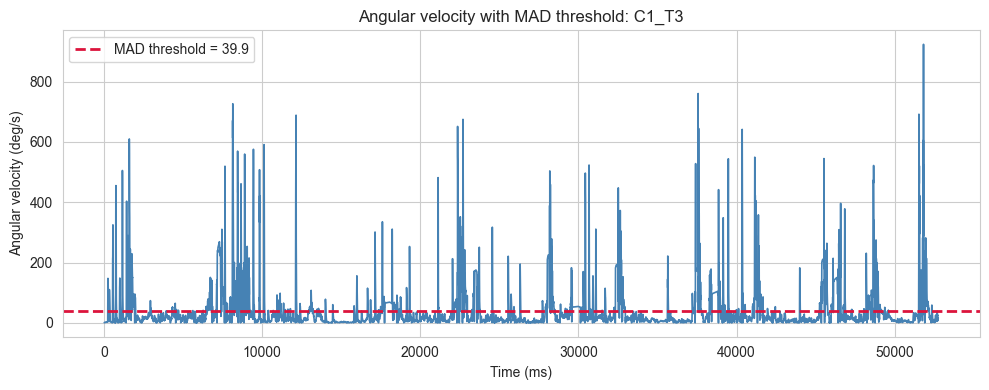

In [88]:
cond = 1
trial = 3

sub = df_clean[
    (df_clean["condition_number"] == cond) &
    (df_clean["trial_number"] == trial)
].copy()

thr = thresholds_df.loc[
    (thresholds_df["condition_number"] == cond) &
    (thresholds_df["trial_number"] == trial),
    "mad_threshold"
].iloc[0]

plt.figure(figsize=(10, 4))
plt.plot(sub["time_ms"], sub["angular_velocity"], lw=1.2, color="steelblue")
plt.axhline(thr, color="crimson", ls="--", lw=2, label=f"MAD threshold = {thr:.1f}")
plt.xlabel("Time (ms)")
plt.ylabel("Angular velocity (deg/s)")
plt.title(f"Angular velocity with MAD threshold: C{cond}_T{trial}")
plt.legend()
plt.tight_layout()
plt.show()


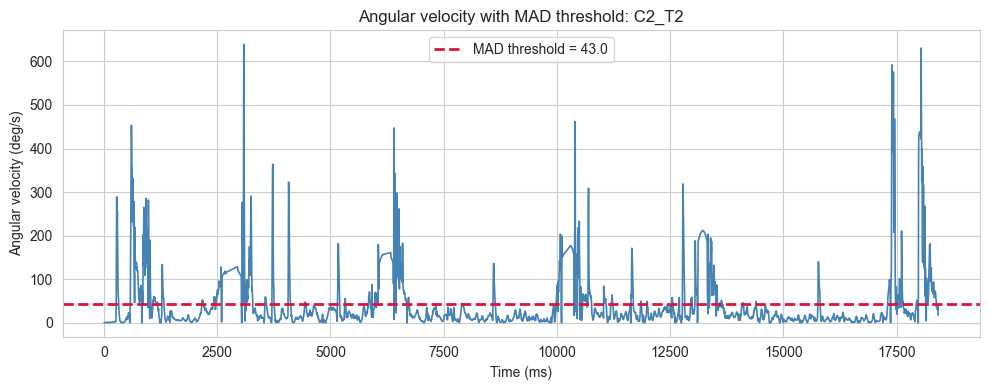

In [74]:
cond = 2
trial = 2

sub = df_clean[
    (df_clean["condition_number"] == cond) &
    (df_clean["trial_number"] == trial)
].copy()

thr = thresholds_df.loc[
    (thresholds_df["condition_number"] == cond) &
    (thresholds_df["trial_number"] == trial),
    "mad_threshold"
].iloc[0]

plt.figure(figsize=(10, 4))
plt.plot(sub["time_ms"], sub["angular_velocity"], lw=1.2, color="steelblue")
plt.axhline(thr, color="crimson", ls="--", lw=2, label=f"MAD threshold = {thr:.1f}")
plt.xlabel("Time (ms)")
plt.ylabel("Angular velocity (deg/s)")
plt.title(f"Angular velocity with MAD threshold: C{cond}_T{trial}")
plt.legend()
plt.tight_layout()
plt.show()


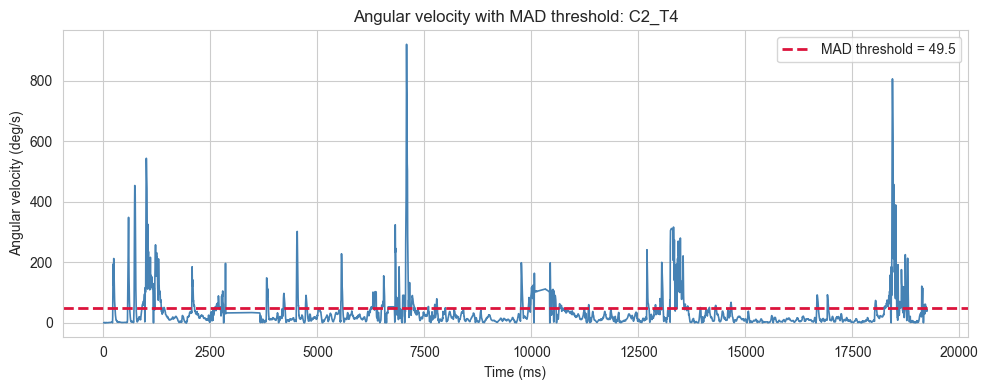

In [85]:
cond = 2
trial = 4

sub = df_clean[
    (df_clean["condition_number"] == cond) &
    (df_clean["trial_number"] == trial)
].copy()

thr = thresholds_df.loc[
    (thresholds_df["condition_number"] == cond) &
    (thresholds_df["trial_number"] == trial),
    "mad_threshold"
].iloc[0]

plt.figure(figsize=(10, 4))
plt.plot(sub["time_ms"], sub["angular_velocity"], lw=1.2, color="steelblue")
plt.axhline(thr, color="crimson", ls="--", lw=2, label=f"MAD threshold = {thr:.1f}")
plt.xlabel("Time (ms)")
plt.ylabel("Angular velocity (deg/s)")
plt.title(f"Angular velocity with MAD threshold: C{cond}_T{trial}")
plt.legend()
plt.tight_layout()
plt.show()

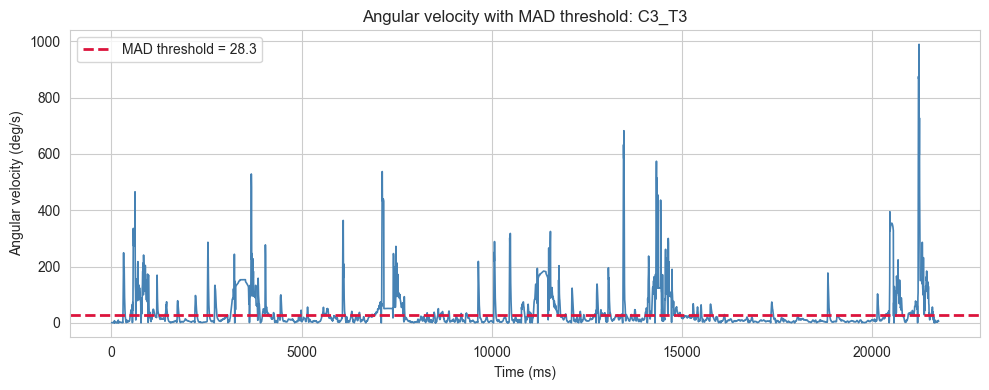

In [86]:
cond = 3
trial = 3

sub = df_clean[
    (df_clean["condition_number"] == cond) &
    (df_clean["trial_number"] == trial)
].copy()

thr = thresholds_df.loc[
    (thresholds_df["condition_number"] == cond) &
    (thresholds_df["trial_number"] == trial),
    "mad_threshold"
].iloc[0]

plt.figure(figsize=(10, 4))
plt.plot(sub["time_ms"], sub["angular_velocity"], lw=1.2, color="steelblue")
plt.axhline(thr, color="crimson", ls="--", lw=2, label=f"MAD threshold = {thr:.1f}")
plt.xlabel("Time (ms)")
plt.ylabel("Angular velocity (deg/s)")
plt.title(f"Angular velocity with MAD threshold: C{cond}_T{trial}")
plt.legend()
plt.tight_layout()
plt.show()


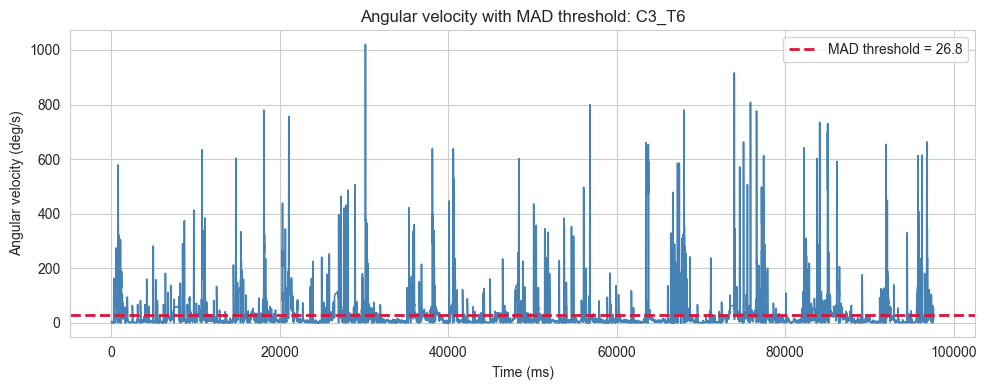

In [87]:
cond = 3
trial = 6

sub = df_clean[
    (df_clean["condition_number"] == cond) &
    (df_clean["trial_number"] == trial)
].copy()

thr = thresholds_df.loc[
    (thresholds_df["condition_number"] == cond) &
    (thresholds_df["trial_number"] == trial),
    "mad_threshold"
].iloc[0]

plt.figure(figsize=(10, 4))
plt.plot(sub["time_ms"], sub["angular_velocity"], lw=1.2, color="steelblue")
plt.axhline(thr, color="crimson", ls="--", lw=2, label=f"MAD threshold = {thr:.1f}")
plt.xlabel("Time (ms)")
plt.ylabel("Angular velocity (deg/s)")
plt.title(f"Angular velocity with MAD threshold: C{cond}_T{trial}")
plt.legend()
plt.tight_layout()
plt.show()


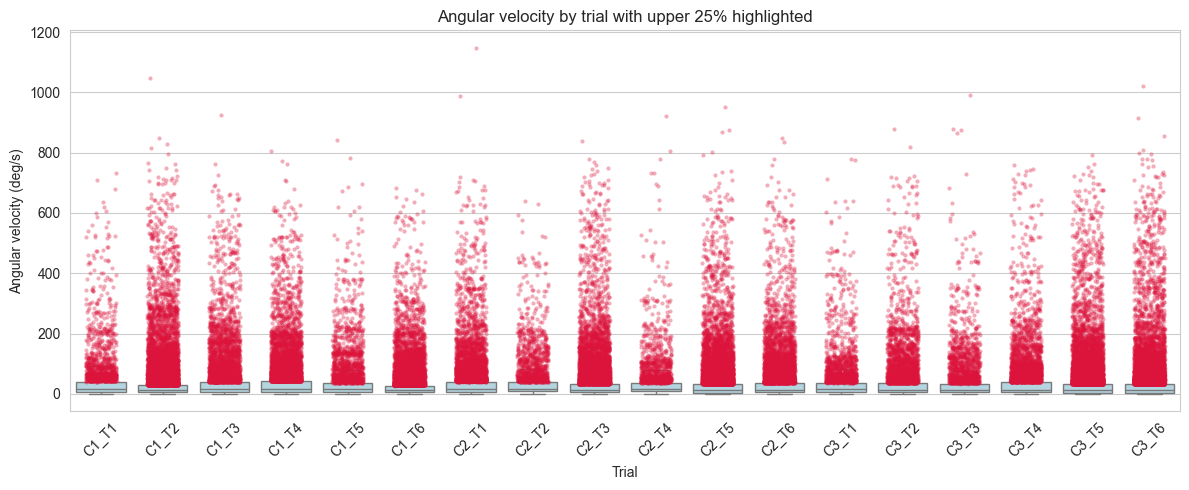

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = df_clean.copy()
plot_df["angular_velocity"] = pd.to_numeric(plot_df["angular_velocity"], errors="coerce")
plot_df = plot_df[np.isfinite(plot_df["angular_velocity"])].copy()

plot_df["trial_label"] = (
    "C" + plot_df["condition_number"].astype(str) +
    "_T" + plot_df["trial_number"].astype(str)
)

# Compute Q3 (75th percentile) per trial
q3_df = (
    plot_df.groupby("trial_label")["angular_velocity"]
    .quantile(0.75)
    .rename("q3")
    .reset_index()
)

plot_df = plot_df.merge(q3_df, on="trial_label", how="left")

# Keep only values above Q3
upper_25_df = plot_df[plot_df["angular_velocity"] > plot_df["q3"]].copy()

plt.figure(figsize=(12, 5))

sns.boxplot(
    data=plot_df,
    x="trial_label",
    y="angular_velocity",
    color="lightblue",
    showfliers=False
)

sns.stripplot(
    data=upper_25_df,
    x="trial_label",
    y="angular_velocity",
    color="crimson",
    size=3,
    alpha=0.35,
    jitter=0.25
)

plt.xticks(rotation=45)
plt.xlabel("Trial")
plt.ylabel("Angular velocity (deg/s)")
plt.title("Angular velocity by trial with upper 25% highlighted")
plt.tight_layout()
plt.show()


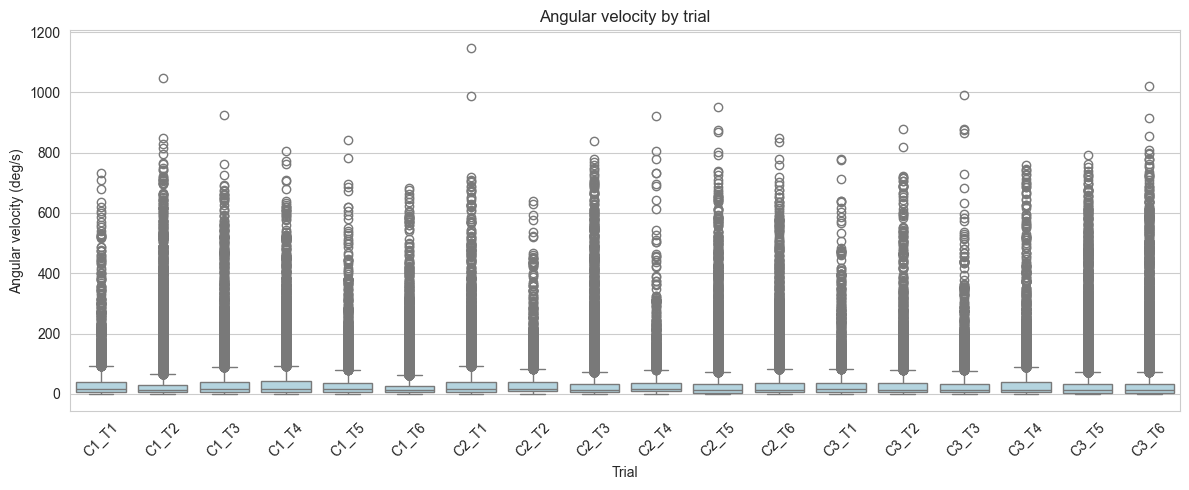

In [22]:
plt.figure(figsize=(12, 5))
sns.boxplot(
    data=plot_df,
    x="trial_label",
    y="angular_velocity",
    color="lightblue",
    showfliers=True
)
plt.xticks(rotation=45)
plt.xlabel("Trial")
plt.ylabel("Angular velocity (deg/s)")
plt.title("Angular velocity by trial")
plt.tight_layout()
plt.show()


In [47]:
df_clean

,gaze_capture_time,raw_timestamp,relative_to_unix_epoch_timestamp,focus_distance,frame_number,stability,status,gaze_forward_x,gaze_forward_y,gaze_forward_z,...,time_ms,good_sample,bad_sample,is_interpolated,clean_gaze_forward_x,clean_gaze_forward_y,clean_gaze_forward_z,segment_label,angular_velocity,mad_threshold
0,1000325694741666500,1773141240816,336.4777,0.975025,584492,0.821958,Valid,0.013115,0.144055,0.989483,...,0.0000,True,False,False,0.013078,0.144172,0.989466,C1_T1,NaN,47.545356
1,1000325694746666700,1773141240816,336.4777,0.977628,584493,0.817059,Valid,0.013078,0.144172,0.989466,...,5.0002,True,False,False,0.013059,0.144225,0.989459,C1_T1,0.653459,47.545356
2,1000325694751663700,1773141240816,336.4777,0.980051,584494,0.827888,Valid,0.013039,0.144279,0.989451,...,9.9972,True,False,False,0.013039,0.144279,0.989451,C1_T1,0.653878,47.545356
3,1000325694756664500,1773141240816,336.4777,0.982777,584495,0.820999,Valid,0.013003,0.144336,0.989443,...,14.9980,True,False,False,0.013003,0.144336,0.989443,C1_T1,0.791661,47.545356
4,1000325694761666200,1773141240824,336.4866,0.985244,584496,0.822582,Valid,0.012964,0.144379,0.989437,...,19.9997,True,False,False,0.012964,0.144336,0.989444,C1_T1,0.443740,47.545356
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
202964,1000328169625686100,1773143715702,1593.0000,0.677271,1079278,0.281021,Valid,0.285666,-0.076886,0.955240,...,97592.3892,True,False,False,0.285666,-0.076886,0.955240,C3_T6,37.569699,26.768627
202965,1000328169630684400,1773143715702,1593.0000,0.681785,1079279,0.310471,Valid,0.287534,-0.074987,0.954831,...,97597.3875,True,False,False,0.287534,-0.074987,0.954830,C3_T6,30.886675,26.768627
202966,1000328169635683800,1773143715702,1593.0000,0.681963,1079280,0.328037,Valid,0.288786,-0.073097,0.954599,...,97602.3869,True,False,False,0.288786,-0.073097,0.954599,C3_T6,26.124483,26.768627
202967,1000328169640683200,1773143715702,1593.0000,0.681368,1079281,0.382888,Valid,0.289915,-0.071516,0.954377,...,97607.3863,True,False,False,0.289351,-0.072306,0.954488,C3_T6,11.203345,26.768627


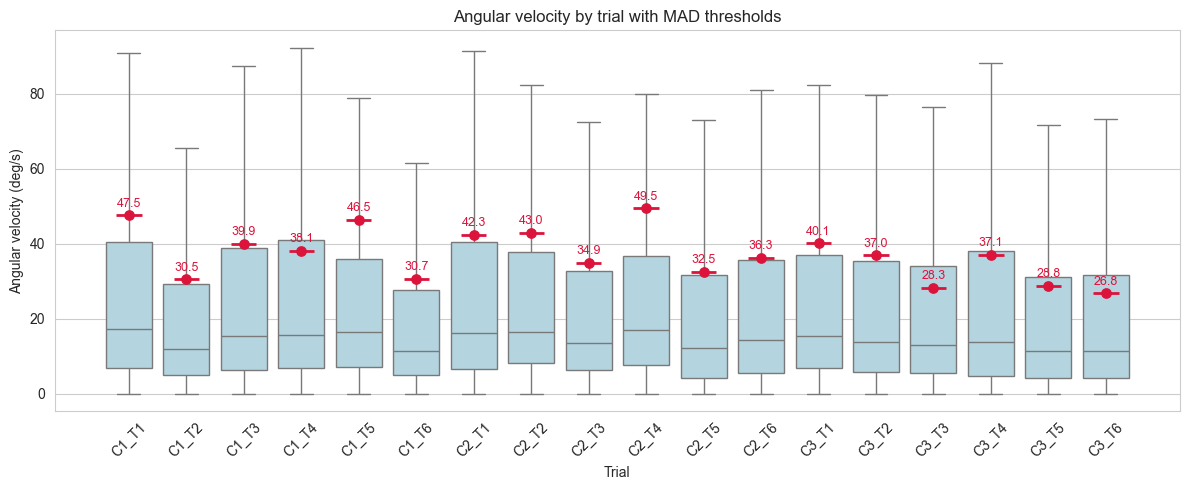

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = df_clean.copy()
plot_df["angular_velocity"] = pd.to_numeric(plot_df["angular_velocity"], errors="coerce")
plot_df = plot_df[np.isfinite(plot_df["angular_velocity"])].copy()

plot_df["trial_label"] = (
    "C" + plot_df["condition_number"].astype(str) +
    "_T" + plot_df["trial_number"].astype(str)
)

thr_df = thresholds_df.copy()
thr_df["trial_label"] = (
    "C" + thr_df["condition_number"].astype(str) +
    "_T" + thr_df["trial_number"].astype(str)
)

trial_order = thr_df["trial_label"].tolist()

plt.figure(figsize=(12, 5))

ax = sns.boxplot(
    data=plot_df,
    x="trial_label",
    y="angular_velocity",
    order=trial_order,
    color="lightblue",
    showfliers=False
)

# Overlay threshold markers and labels
for i, row in enumerate(thr_df.itertuples(index=False)):
    y = row.mad_threshold

    # red point
    ax.scatter(i, y, color="crimson", s=45, zorder=5)

    # short horizontal line centered on the box
    ax.hlines(
        y=y,
        xmin=i - 0.22,
        xmax=i + 0.22,
        color="crimson",
        linewidth=2,
        zorder=4
    )

    # numeric label
    ax.text(
        i,
        y + 1.5,
        f"{y:.1f}",
        color="crimson",
        ha="center",
        va="bottom",
        fontsize=9,
        rotation=0
    )

plt.xticks(rotation=45)
plt.xlabel("Trial")
plt.ylabel("Angular velocity (deg/s)")
plt.title("Angular velocity by trial with MAD thresholds")
plt.tight_layout()
plt.show()


In [24]:
thresholds_df

,condition_number,trial_number,mad_threshold,n_valid_velocity_samples,threshold_trace
0,1,1,47.545356,4000,"[200.0, 67.12252098048681, 56.73807653430477, ..."
1,1,2,30.513328,21652,"[200.0, 47.546587696019955, 35.66597461796522,..."
2,1,3,39.929693,10275,"[200.0, 61.44415402006579, 47.319312465055994,..."
3,1,4,38.122529,12823,"[200.0, 60.85333688610654, 45.242153186966384,..."
4,1,5,46.450668,4650,"[200.0, 63.049954925827514, 50.54976182789622,..."
5,1,6,30.741801,15073,"[200.0, 45.722265484097775, 35.12651702032802,..."
6,2,1,42.348515,10646,"[200.0, 64.76391384959867, 50.10219028061774, ..."
7,2,2,42.990368,3545,"[200.0, 61.47558527203046, 47.98479963808909, ..."
8,2,3,34.941136,18792,"[200.0, 51.882216183104255, 40.598495947675616..."
9,2,4,49.484594,3705,"[200.0, 66.7542871314604, 55.494457376753374, ..."


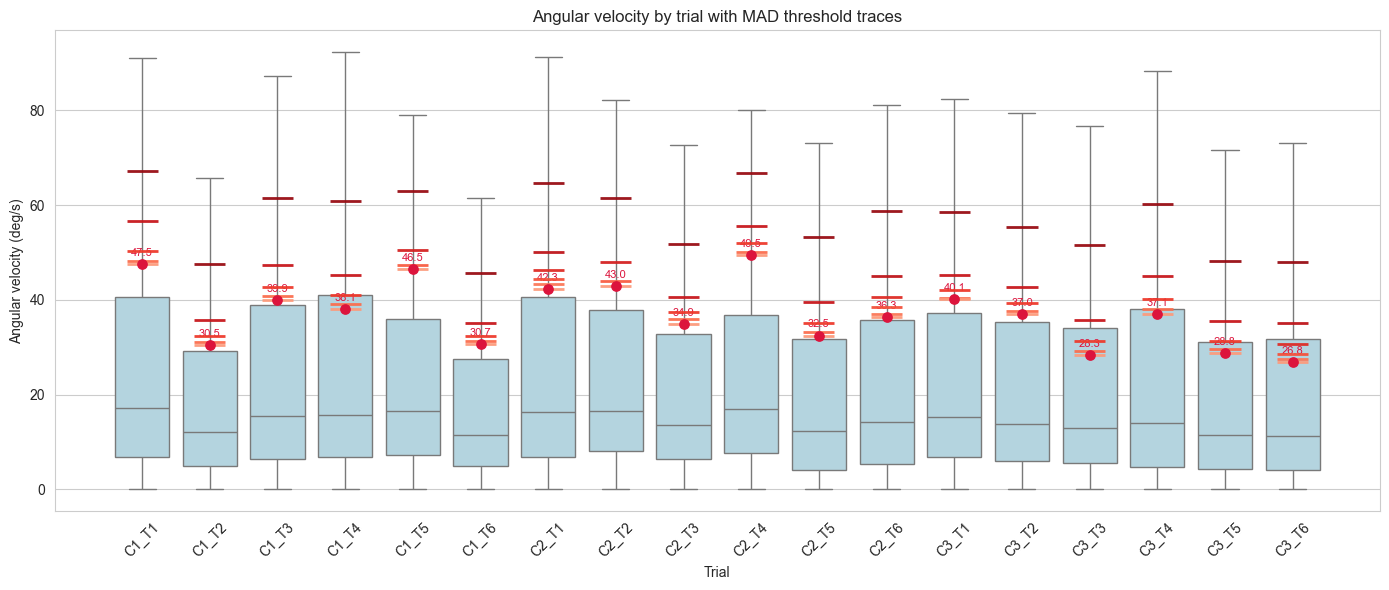

In [54]:

plot_df = df_clean.copy()
plot_df["angular_velocity"] = pd.to_numeric(plot_df["angular_velocity"], errors="coerce")
plot_df = plot_df[np.isfinite(plot_df["angular_velocity"])].copy()

plot_df["trial_label"] = (
    "C" + plot_df["condition_number"].astype(str) +
    "_T" + plot_df["trial_number"].astype(str)
)

thr_df = thresholds_df.copy()
thr_df["trial_label"] = (
    "C" + thr_df["condition_number"].astype(str) +
    "_T" + thr_df["trial_number"].astype(str)
)

# In case threshold_trace was saved as text instead of Python list
def parse_trace(x):
    if isinstance(x, list):
        return x
    if pd.isna(x):
        return []
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except Exception:
            return []
    return []

thr_df["threshold_trace"] = thr_df["threshold_trace"].apply(parse_trace)

trial_order = thr_df["trial_label"].tolist()

plt.figure(figsize=(14, 6))

ax = sns.boxplot(
    data=plot_df,
    x="trial_label",
    y="angular_velocity",
    order=trial_order,
    color="lightblue",
    showfliers=False
)

# Colormap from dark red to bright red
cmap = plt.cm.Reds

for i, row in enumerate(thr_df.itertuples(index=False)):
    trace = row.threshold_trace[1:] if len(row.threshold_trace) > 1 else []


    if not trace:
        continue

    n = len(trace)

    for j, y in enumerate(trace):
        # darker for early values, brighter for later values
        color = cmap(0.90 - 0.55 * (j / max(n - 1, 1)))


        ax.hlines(
            y=y,
            xmin=i - 0.23,
            xmax=i + 0.23,
            color=color,
            linewidth=2,
            alpha=0.95,
            zorder=4
        )

    # final threshold point
    final_y = trace[-1]
    ax.scatter(i, final_y, color="crimson", s=45, zorder=5)

    # final threshold label
    ax.text(
        i,
        final_y + 1.3,
        f"{final_y:.1f}",
        color="crimson",
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.xticks(rotation=45)
plt.xlabel("Trial")
plt.ylabel("Angular velocity (deg/s)")
plt.title("Angular velocity by trial with MAD threshold traces")
plt.tight_layout()
plt.show()


In [27]:
from matplotlib.colors import LinearSegmentedColormap

red_grad = LinearSegmentedColormap.from_list(
    "custom_red_grad",
    ["#5a0000", "#8b0000", "#c1121f", "#ff5a5f"]
)


In [28]:
for i, row in enumerate(thr_df.itertuples(index=False)):
    trace = row.threshold_trace[1:] if len(row.threshold_trace) > 1 else []

    if not trace:
        continue

    n = len(trace)

    for j, y in enumerate(trace):
        color = red_grad(j / max(n - 1, 1))

        ax.hlines(
            y=y,
            xmin=i - 0.23,
            xmax=i + 0.23,
            color=color,
            linewidth=2.2,
            alpha=1.0,
            zorder=4
        )

    final_y = trace[-1]
    ax.scatter(i, final_y, color="#ff2d2d", s=45, zorder=5)

    ax.text(
        i,
        final_y + 1.3,
        f"{final_y:.1f}",
        color="#cc1111",
        ha="center",
        va="bottom",
        fontsize=8
    )


In [ ]:
ax.scatter(
    i,
    y,
    color=color,
    s=28,
    alpha=0.98,
    zorder=4
)

/var/folders/8l/z8l1m1lj7mq_w4vz174c40xh0000gn/T/ipykernel_20392/2014922515.py:147: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


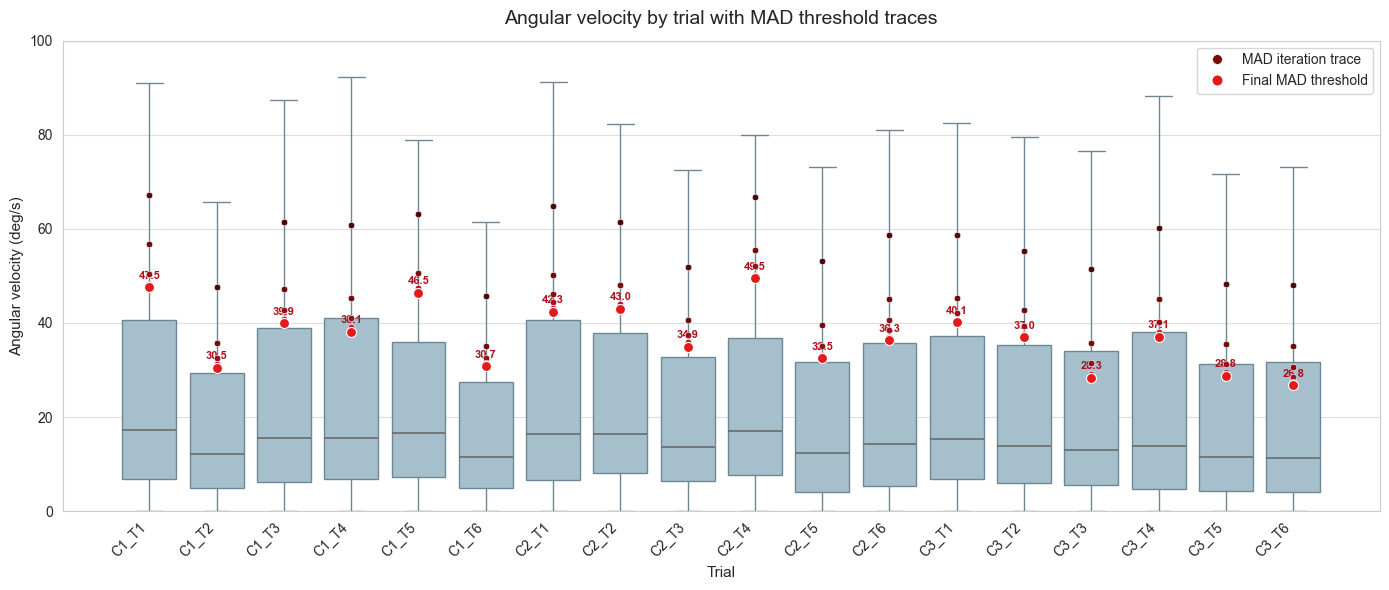

In [55]:
# -----------------------------
# Prepare data
# -----------------------------
plot_df = df_clean.copy()
plot_df["angular_velocity"] = pd.to_numeric(plot_df["angular_velocity"], errors="coerce")
plot_df = plot_df[np.isfinite(plot_df["angular_velocity"])].copy()

plot_df["trial_label"] = (
    "C" + plot_df["condition_number"].astype(str) +
    "_T" + plot_df["trial_number"].astype(str)
)

thr_df = thresholds_df.copy()
thr_df["trial_label"] = (
    "C" + thr_df["condition_number"].astype(str) +
    "_T" + thr_df["trial_number"].astype(str)
)

def parse_trace(x):
    if isinstance(x, list):
        return x
    if pd.isna(x):
        return []
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except Exception:
            return []
    return []

thr_df["threshold_trace"] = thr_df["threshold_trace"].apply(parse_trace)

trial_order = (
    thr_df.sort_values(["condition_number", "trial_number"])["trial_label"]
    .tolist()
)

thr_df = (
    thr_df.set_index("trial_label")
    .loc[trial_order]
    .reset_index()
)

# -----------------------------
# Style
# -----------------------------
sns.set_style("whitegrid")

# Dark red -> vivid bright red
red_grad = LinearSegmentedColormap.from_list(
    "mad_red_grad",
    ["#4a0404", "#7a0a0a", "#b11226", "#ff4d5a"]
)

box_face = "#9ec3d3"
box_edge = "#6e8893"
median_color = "#6b6b6b"
final_point_color = "#e31a1c"
final_text_color = "#b10f1a"

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(14, 6))

sns.boxplot(
    data=plot_df,
    x="trial_label",
    y="angular_velocity",
    order=trial_order,
    color=box_face,
    showfliers=False,
    linewidth=1.0,
    boxprops=dict(edgecolor=box_edge),
    whiskerprops=dict(color=box_edge, linewidth=1.0),
    capprops=dict(color=box_edge, linewidth=1.0),
    medianprops=dict(color=median_color, linewidth=1.2),
    ax=ax
)

# -----------------------------
# Overlay threshold traces
# Exclude the initial 200 deg/s
# -----------------------------
for i, row in enumerate(thr_df.itertuples(index=False)):
    trace_all = row.threshold_trace
    trace = trace_all[1:] if len(trace_all) > 1 else []

    trace = [t for t in trace if np.isfinite(t)]

    if not trace:
        continue

    n = len(trace)

    for j, y in enumerate(trace):
        frac = j / max(n - 1, 1)
        color = red_grad(frac)

        # Early iterations slightly thinner, later ones stronger
        lw = 1.5 + 1.0 * frac




        ax.scatter(
            i,
            y,
            color=color,
            s=22,
            edgecolor="white",
            linewidth=0.4,
            alpha=0.98,
            zorder=4
        )

    final_y = trace[-1]

    ax.scatter(
        i,
        final_y,
        color=final_point_color,
        edgecolor="white",
        linewidth=0.8,
        s=52,
        zorder=5
    )

    ax.text(
        i,
        final_y + 1.4,
        f"{final_y:.1f}",
        color=final_text_color,
        ha="center",
        va="bottom",
        fontsize=8,
        fontweight="semibold"
    )

# -----------------------------
# Labels and limits
# -----------------------------
ax.set_xlabel("Trial", fontsize=11)
ax.set_ylabel("Angular velocity (deg/s)", fontsize=11)
ax.set_title("Angular velocity by trial with MAD threshold traces", fontsize=14, pad=12)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.set_ylim(0, 100)

# Lighten grid a bit for presentation clarity
ax.grid(axis="y", color="#d0d0d0", alpha=0.7)
ax.grid(axis="x", visible=False)

# -----------------------------
# Legend
# -----------------------------
legend_elements = [
    Line2D(
        [0], [0],
        marker="o",
        color="w",
        markerfacecolor="#7a0a0a",
        markeredgecolor="white",
        markeredgewidth=0.4,
        markersize=7,
        label="MAD iteration trace"
    ),
    Line2D(
        [0], [0],
        marker="o",
        color="w",
        markerfacecolor=final_point_color,
        markeredgecolor="white",
        markeredgewidth=0.8,
        markersize=8,
        label="Final MAD threshold"
    ),
]




ax.legend(handles=legend_elements, loc="upper right", frameon=True)

plt.tight_layout()
plt.show()


/var/folders/8l/z8l1m1lj7mq_w4vz174c40xh0000gn/T/ipykernel_20392/2014922515.py:147: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


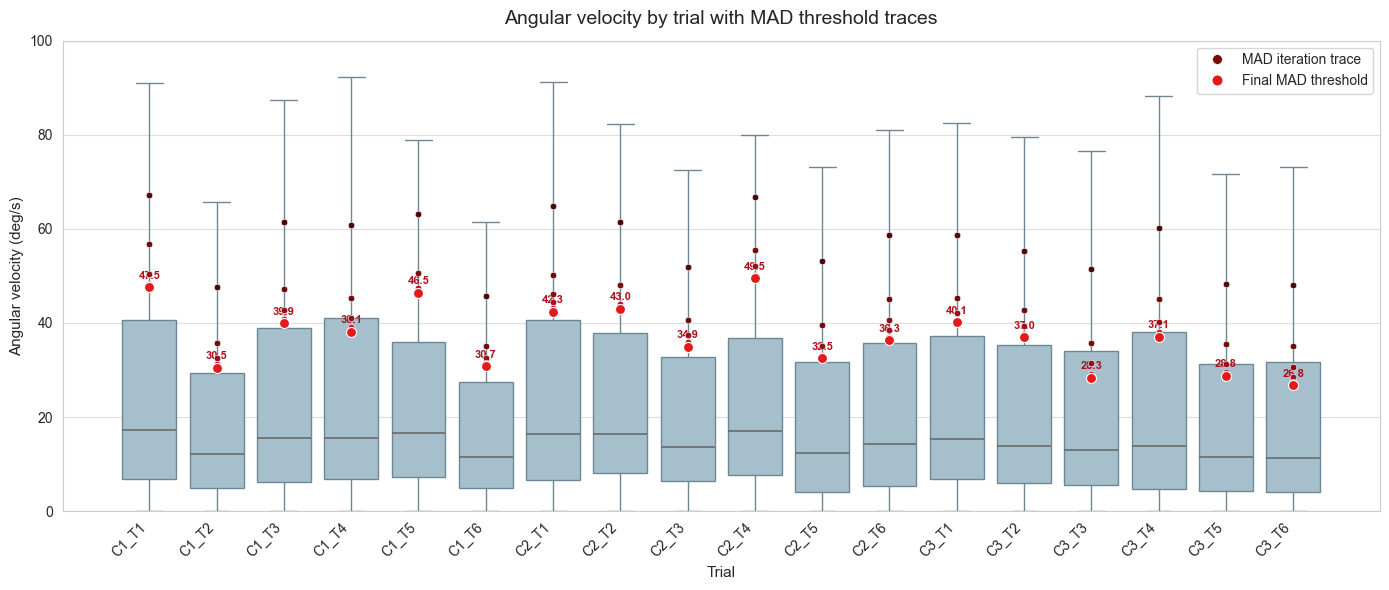

In [56]:
# -----------------------------
# Prepare data
# -----------------------------
plot_df = df_clean.copy()
plot_df["angular_velocity"] = pd.to_numeric(plot_df["angular_velocity"], errors="coerce")
plot_df = plot_df[np.isfinite(plot_df["angular_velocity"])].copy()

plot_df["trial_label"] = (
    "C" + plot_df["condition_number"].astype(str) +
    "_T" + plot_df["trial_number"].astype(str)
)

thr_df = thresholds_df.copy()
thr_df["trial_label"] = (
    "C" + thr_df["condition_number"].astype(str) +
    "_T" + thr_df["trial_number"].astype(str)
)

def parse_trace(x):
    if isinstance(x, list):
        return x
    if pd.isna(x):
        return []
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except Exception:
            return []
    return []

thr_df["threshold_trace"] = thr_df["threshold_trace"].apply(parse_trace)

trial_order = (
    thr_df.sort_values(["condition_number", "trial_number"])["trial_label"]
    .tolist()
)

thr_df = (
    thr_df.set_index("trial_label")
    .loc[trial_order]
    .reset_index()
)

# -----------------------------
# Style
# -----------------------------
sns.set_style("whitegrid")

# Dark red -> vivid bright red
red_grad = LinearSegmentedColormap.from_list(
    "mad_red_grad",
    ["#4a0404", "#7a0a0a", "#b11226", "#ff4d5a"]
)

box_face = "#9ec3d3"
box_edge = "#6e8893"
median_color = "#6b6b6b"
final_point_color = "#e31a1c"
final_text_color = "#b10f1a"

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(14, 6))

sns.boxplot(
    data=plot_df,
    x="trial_label",
    y="angular_velocity",
    order=trial_order,
    color=box_face,
    showfliers=False,
    linewidth=1.0,
    boxprops=dict(edgecolor=box_edge),
    whiskerprops=dict(color=box_edge, linewidth=1.0),
    capprops=dict(color=box_edge, linewidth=1.0),
    medianprops=dict(color=median_color, linewidth=1.2),
    ax=ax
)

# -----------------------------
# Overlay threshold traces
# Exclude the initial 200 deg/s
# -----------------------------
for i, row in enumerate(thr_df.itertuples(index=False)):
    trace_all = row.threshold_trace
    trace = trace_all[1:] if len(trace_all) > 1 else []

    trace = [t for t in trace if np.isfinite(t)]

    if not trace:
        continue

    n = len(trace)

    for j, y in enumerate(trace):
        frac = j / max(n - 1, 1)
        color = red_grad(frac)

        # Early iterations slightly thinner, later ones stronger
        lw = 1.5 + 1.0 * frac




        ax.scatter(
            i,
            y,
            color=color,
            s=22,
            edgecolor="white",
            linewidth=0.4,
            alpha=0.98,
            zorder=4
        )

    final_y = trace[-1]

    ax.scatter(
        i,
        final_y,
        color=final_point_color,
        edgecolor="white",
        linewidth=0.8,
        s=52,
        zorder=5
    )

    ax.text(
        i,
        final_y + 1.4,
        f"{final_y:.1f}",
        color=final_text_color,
        ha="center",
        va="bottom",
        fontsize=8,
        fontweight="semibold"
    )

# -----------------------------
# Labels and limits
# -----------------------------
ax.set_xlabel("Trial", fontsize=11)
ax.set_ylabel("Angular velocity (deg/s)", fontsize=11)
ax.set_title("Angular velocity by trial with MAD threshold traces", fontsize=14, pad=12)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.set_ylim(0, 100)

# Lighten grid a bit for presentation clarity
ax.grid(axis="y", color="#d0d0d0", alpha=0.7)
ax.grid(axis="x", visible=False)

# -----------------------------
# Legend
# -----------------------------
legend_elements = [
    Line2D(
        [0], [0],
        marker="o",
        color="w",
        markerfacecolor="#7a0a0a",
        markeredgecolor="white",
        markeredgewidth=0.4,
        markersize=7,
        label="MAD iteration trace"
    ),
    Line2D(
        [0], [0],
        marker="o",
        color="w",
        markerfacecolor=final_point_color,
        markeredgecolor="white",
        markeredgewidth=0.8,
        markersize=8,
        label="Final MAD threshold"
    ),
]




ax.legend(handles=legend_elements, loc="upper right", frameon=True)

plt.tight_layout()
plt.show()


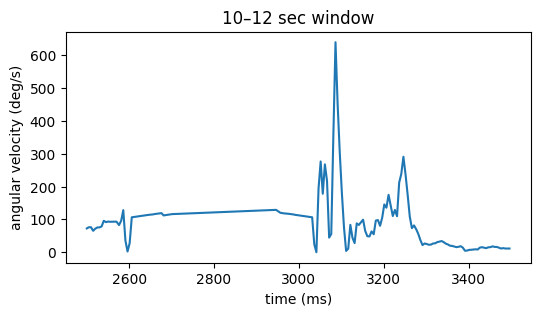

In [109]:
sub = df_clean[
    (df_clean["condition_number"] == 2) &
    (df_clean["trial_number"] == 2) &
    (df_clean["time_ms"] >= 2500) &   # 10 sec
    (df_clean["time_ms"] <= 3500)     # 12 sec
].copy()

plt.figure(figsize=(6,3))
plt.plot(sub["time_ms"], sub["angular_velocity"])
plt.xlabel("time (ms)")
plt.ylabel("angular velocity (deg/s)")
plt.title("10–12 sec window")
plt.show()

## Outliers

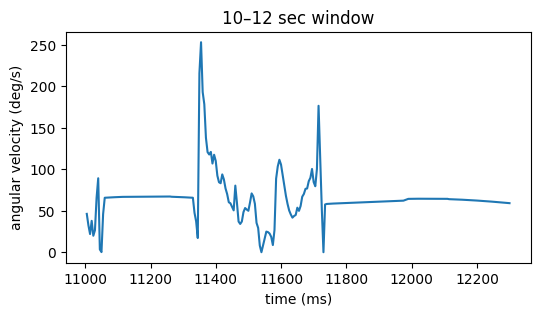

In [114]:
sub = df_clean[
    (df_clean["condition_number"] == 1) &
    (df_clean["trial_number"] == 1) &
    (df_clean["time_ms"] >= 11000) &   # 10 sec
    (df_clean["time_ms"] <= 12300)     # 12 sec
].copy()

plt.figure(figsize=(6,3))
plt.plot(sub["time_ms"], sub["angular_velocity"])
plt.xlabel("time (ms)")
plt.ylabel("angular velocity (deg/s)")
plt.title("10–12 sec window")
plt.show()

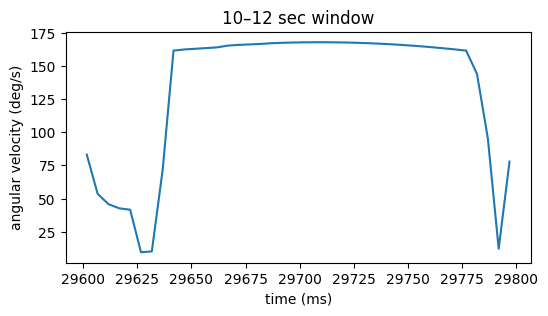

In [111]:
sub = df_clean[
    (df_clean["condition_number"] == 1) &
    (df_clean["trial_number"] == 4) &
    (df_clean["time_ms"] >= 29600) &   # 10 sec
    (df_clean["time_ms"] <= 29800)     # 12 sec
].copy()

plt.figure(figsize=(6,3))
plt.plot(sub["time_ms"], sub["angular_velocity"])
plt.xlabel("time (ms)")
plt.ylabel("angular velocity (deg/s)")
plt.title("10–12 sec window")
plt.show()

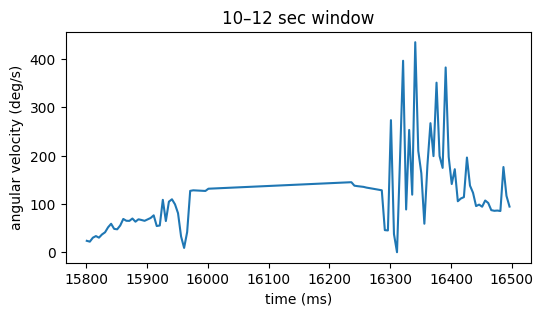

In [112]:
sub = df_clean[
    (df_clean["condition_number"] == 1) &
    (df_clean["trial_number"] == 4) &
    (df_clean["time_ms"] >= 15800) &   # 10 sec
    (df_clean["time_ms"] <= 16500)     # 12 sec
].copy()

plt.figure(figsize=(6,3))
plt.plot(sub["time_ms"], sub["angular_velocity"])
plt.xlabel("time (ms)")
plt.ylabel("angular velocity (deg/s)")
plt.title("10–12 sec window")
plt.show()

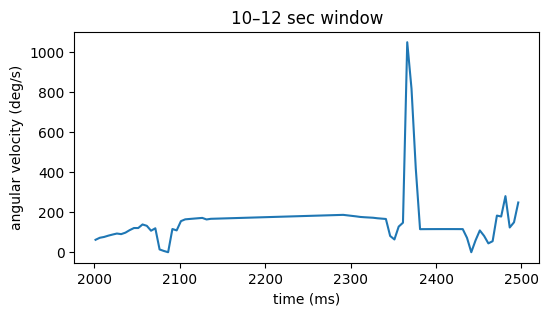

In [113]:
sub = df_clean[
    (df_clean["condition_number"] == 1) &
    (df_clean["trial_number"] == 2) &
    (df_clean["time_ms"] >= 2000) &   # 10 sec
    (df_clean["time_ms"] <= 2500)     # 12 sec
].copy()

plt.figure(figsize=(6,3))
plt.plot(sub["time_ms"], sub["angular_velocity"])
plt.xlabel("time (ms)")
plt.ylabel("angular velocity (deg/s)")
plt.title("10–12 sec window")
plt.show()

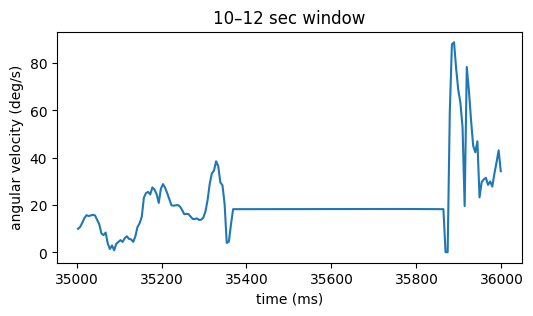

In [48]:
sub = df_clean[
    (df_clean["condition_number"] == 3) &
    (df_clean["trial_number"] == 5) &
    (df_clean["time_ms"] >= 35000) &   # 10 sec
    (df_clean["time_ms"] <= 36000)     # 12 sec
].copy()

plt.figure(figsize=(6,3))
plt.plot(sub["time_ms"], sub["angular_velocity"])
plt.xlabel("time (ms)")
plt.ylabel("angular velocity (deg/s)")
plt.title("10–12 sec window")
plt.show()

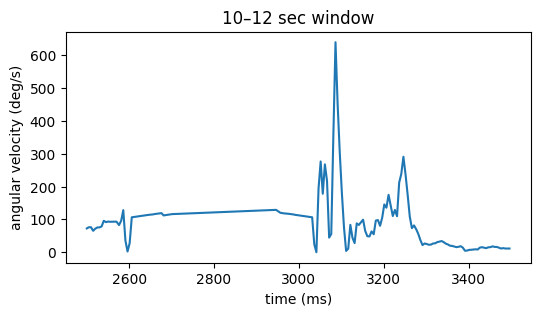

In [118]:
sub = df_clean[
    (df_clean["condition_number"] == 2) &
    (df_clean["trial_number"] == 2) &
    (df_clean["time_ms"] >= 2500) &   # 2.5 sec
    (df_clean["time_ms"] <= 3500)     # 3.5 sec
].copy()

plt.figure(figsize=(6,3))
plt.plot(sub["time_ms"], sub["angular_velocity"])
plt.xlabel("time (ms)")
plt.ylabel("angular velocity (deg/s)")
plt.title("10–12 sec window")
plt.show()

In [41]:
df_clean["clean_gaze_forward_x"].isnull()

0         False
1         False
2         False
3         False
4         False
          ...  
202964    False
202965    False
202966    False
202967    False
202968    False
Name: clean_gaze_forward_x, Length: 202969, dtype: bool

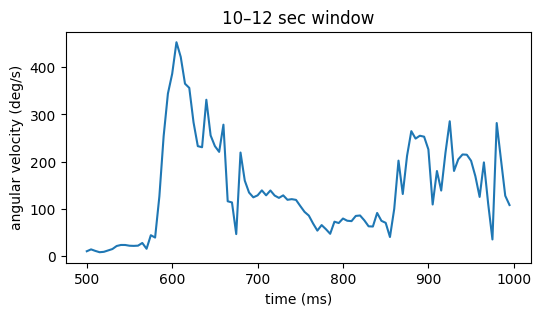

In [38]:
sub = df_clean[
    (df_clean["condition_number"] == 2) &
    (df_clean["trial_number"] == 2) &
    (df_clean["time_ms"] >= 500) &   # 10 sec
    (df_clean["time_ms"] <= 1000)     # 12 sec
].copy()

plt.figure(figsize=(6,3))
plt.plot(sub["time_ms"], sub["angular_velocity"])
plt.xlabel("time (ms)")
plt.ylabel("angular velocity (deg/s)")
plt.title("10–12 sec window")
plt.show()

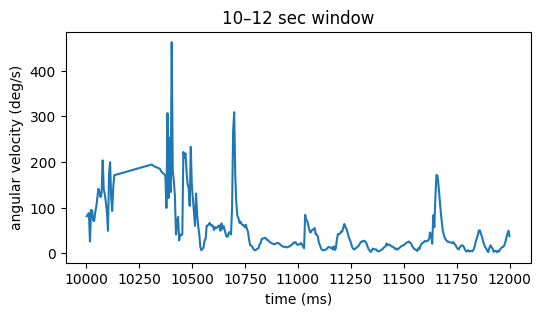

In [39]:
sub = df_clean[
    (df_clean["condition_number"] == 2) &
    (df_clean["trial_number"] == 2) &
    (df_clean["time_ms"] >= 10000) &   # 10 sec
    (df_clean["time_ms"] <= 12000)     # 12 sec
].copy()

plt.figure(figsize=(6,3))
plt.plot(sub["time_ms"], sub["angular_velocity"])
plt.xlabel("time (ms)")
plt.ylabel("angular velocity (deg/s)")
plt.title("10–12 sec window")
plt.show()

In [116]:
df_clean = add_velocity_category(df_clean)

In [63]:
df_clean

,gaze_capture_time,raw_timestamp,relative_to_unix_epoch_timestamp,focus_distance,frame_number,stability,status,gaze_forward_x,gaze_forward_y,gaze_forward_z,...,good_sample,bad_sample,is_interpolated,is_rejected,clean_gaze_forward_x,clean_gaze_forward_y,clean_gaze_forward_z,segment_label,angular_velocity,velocity_category
0,1000325694741666500,1773141240816,336.4777,0.975025,584492,0.821958,Valid,0.013115,0.144055,0.989483,...,True,False,False,False,0.013115,0.144055,0.989483,C1_T1,NaN,NaN
1,1000325694746666700,1773141240816,336.4777,0.977628,584493,0.817059,Valid,0.013078,0.144172,0.989466,...,True,False,False,False,0.013078,0.144172,0.989466,C1_T1,1.420650,fixation
2,1000325694751663700,1773141240816,336.4777,0.980051,584494,0.827888,Valid,0.013039,0.144279,0.989451,...,True,False,False,False,0.013039,0.144279,0.989451,C1_T1,1.307756,fixation
3,1000325694756664500,1773141240816,336.4777,0.982777,584495,0.820999,Valid,0.013003,0.144336,0.989443,...,True,False,False,False,0.013003,0.144336,0.989443,C1_T1,0.791661,fixation
4,1000325694761666200,1773141240824,336.4866,0.985244,584496,0.822582,Valid,0.012964,0.144379,0.989437,...,True,False,False,False,0.012964,0.144379,0.989438,C1_T1,0.664515,fixation
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
202964,1000328169625686100,1773143715702,1593.0000,0.677271,1079278,0.281021,Valid,0.285666,-0.076886,0.955240,...,True,False,False,False,0.285666,-0.076886,0.955240,C3_T6,37.569699,pursuit
202965,1000328169630684400,1773143715702,1593.0000,0.681785,1079279,0.310471,Valid,0.287534,-0.074987,0.954831,...,True,False,False,False,0.287534,-0.074987,0.954830,C3_T6,30.886675,pursuit
202966,1000328169635683800,1773143715702,1593.0000,0.681963,1079280,0.328037,Valid,0.288786,-0.073097,0.954599,...,True,False,False,False,0.288786,-0.073097,0.954599,C3_T6,26.124483,fixation
202967,1000328169640683200,1773143715702,1593.0000,0.681368,1079281,0.382888,Valid,0.289915,-0.071516,0.954377,...,True,False,False,False,0.289915,-0.071516,0.954377,C3_T6,22.406689,fixation


In [25]:
# sort first (important)
df_tmp = df_clean.sort_values(
    ["condition_number", "trial_number", "gaze_capture_time"]
)

# compute dt in seconds
t = df_tmp["gaze_capture_time"].to_numpy(dtype=np.int64)
dt = np.diff(t) * 1e-9  # ns → s

# inspect
print("dt stats (s):")
print("mean:", dt.mean())
print("median:", np.median(dt))
print("min:", dt.min())
print("max:", dt.max())

dt stats (s):
mean: 0.012193567535769187
median: 0.0050006
min: 0.0039648
max: 651.1516063


In [31]:
df_tmp

,gaze_capture_time,raw_timestamp,relative_to_unix_epoch_timestamp,focus_distance,frame_number,stability,status,gaze_forward_x,gaze_forward_y,gaze_forward_z,...,good_sample,bad_sample,is_interpolated,is_rejected,clean_gaze_forward_x,clean_gaze_forward_y,clean_gaze_forward_z,segment_label,angular_velocity,velocity_category
0,1000325694741666500,1773141240816,336.4777,0.975025,584492,0.821958,Valid,0.013115,0.144055,0.989483,...,True,False,False,False,0.013115,0.144055,0.989483,C1_T1,NaN,NaN
1,1000325694746666700,1773141240816,336.4777,0.977628,584493,0.817059,Valid,0.013078,0.144172,0.989466,...,True,False,False,False,0.013078,0.144172,0.989466,C1_T1,1.420650,fixation
2,1000325694751663700,1773141240816,336.4777,0.980051,584494,0.827888,Valid,0.013039,0.144279,0.989451,...,True,False,False,False,0.013039,0.144279,0.989451,C1_T1,1.307756,fixation
3,1000325694756664500,1773141240816,336.4777,0.982777,584495,0.820999,Valid,0.013003,0.144336,0.989443,...,True,False,False,False,0.013003,0.144336,0.989443,C1_T1,0.791661,fixation
4,1000325694761666200,1773141240824,336.4866,0.985244,584496,0.822582,Valid,0.012964,0.144379,0.989437,...,True,False,False,False,0.012964,0.144379,0.989438,C1_T1,0.664515,fixation
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
202964,1000328169625686100,1773143715702,1593.0000,0.677271,1079278,0.281021,Valid,0.285666,-0.076886,0.955240,...,True,False,False,False,0.285666,-0.076886,0.955240,C3_T6,37.569699,pursuit
202965,1000328169630684400,1773143715702,1593.0000,0.681785,1079279,0.310471,Valid,0.287534,-0.074987,0.954831,...,True,False,False,False,0.287534,-0.074987,0.954830,C3_T6,30.886675,pursuit
202966,1000328169635683800,1773143715702,1593.0000,0.681963,1079280,0.328037,Valid,0.288786,-0.073097,0.954599,...,True,False,False,False,0.288786,-0.073097,0.954599,C3_T6,26.124483,fixation
202967,1000328169640683200,1773143715702,1593.0000,0.681368,1079281,0.382888,Valid,0.289915,-0.071516,0.954377,...,True,False,False,False,0.289915,-0.071516,0.954377,C3_T6,22.406689,fixation
